# One-Phonon Diffuse Scattering — Fit to Experimental Data (6o2h, P1)

One rigid body per unit cell (the lysozyme molecule), 6 degrees of freedom
per cell: a rotation $\Omega$ and a translation $v$. The crystal's phonons
are the normal modes of a Born–von Kármán lattice of these rigid bodies,
coupled through a small set of pairwise contact springs. This notebook fits
the contact stiffnesses directly to the **experimental** diffuse-scattering
maps deposited at [CXIDB ID 128](https://www.cxidb.org/id-128.html)
(`triclinic_lysozyme_maps.h5`), the processed reciprocal-space maps
associated with

> Meisburger, S. P., Case, D. A. & Ando, N. *Diffuse X-ray Scattering from
> Correlated Motions in a Protein Crystal.* Nat. Commun. 11, 1271 (2020).

No synthetic data is used anywhere below: the "ground truth" available for
comparison is the deposited 6o2h structure's own refined B-factors and (where
present) ANISOU records, and the held-out fraction of the experimental
diffuse data itself ($R_{\rm free}$).

**Pipeline:** deposited structure + experimental map metadata → matched
$(h,k,l)$ sampling grid → hybrid electron density → coupling vector
$G(\mathbf q)$ → contact detection and framing → dynamical matrix →
data-driven resolution/SNR scan of the experimental map → refinement of
contact stiffnesses to the experimental data → band-structure convergence →
predicted vs. deposited atomic displacement parameters → mode animations.

**Required input files** (same directory as this notebook):
`6o2h.cif`, `6o2h-sf.cif`, and `triclinic_lysozyme_maps.h5` (1.94 GB,
downloaded separately from CXIDB — too large to fetch from inside the
notebook itself).


In [1]:
import io
import pathlib
from itertools import product

import numpy as np
import h5py
import gemmi
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.lines import Line2D
import scipy.constants as const
from scipy.spatial import cKDTree
from scipy.linalg import eigh
from scipy.ndimage import zoom as nd_zoom
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components as sc_connected_components
from scipy.optimize import minimize
from scipy.spatial.transform import Rotation as Rot
import imageio
import imageio.v2 as iio2
from skimage.measure import marching_cubes
from IPython.display import Image as IPImage, display
import gc

np.set_printoptions(precision=4, suppress=True)

def fig_to_image(fig, dpi=72):
    """Rasterize a matplotlib figure to an RGB array, for building GIFs."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    buf.seek(0)
    return iio2.imread(buf)[:, :, :3]


In [2]:
PDB_FILE = pathlib.Path("6o2h.cif")
SF_CIF   = pathlib.Path("6o2h-sf.cif")
H5_FILE  = pathlib.Path("triclinic_lysozyme_maps.h5")

# CXIDB 128 stores three Bragg-subtracted "processed" estimates of the diffuse
# component (half_integer / interpolated_7x7x7 / variational) plus a raw
# total-scattering map and simulated comparison maps (see the README). The
# variational estimate is the one used for the lattice-dynamics fit in the
# original paper, so it's the default here; switch this to cross-check
# against the other processed estimates.
MAP_GROUP = "maps/processed/variational"

D_MIN_MODEL    = 1.5    # Å — resolution for model density (phases)
RATE_MODEL     = 1.5
CONTACT_CUTOFF = 4.0    # Å — atom-atom cutoff defining a rigid-body contact
MIN_CONTACTS   = 5      # minimum atom-atom pairs for a contact to count
MAX_IMAGE      = 1      # search ±MAX_IMAGE unit cells in each direction
TEMPERATURE    = 300.0  # K — used only for the frequency-unit conversion

LAMBDA_REG     = 0.05   # regularization weight on local-frame T–R coupling

N_FIT_MAX      = 1500   # cap on the number of experimental q-points used in
                        # the refinement (memory/runtime control — the
                        # candidate pool from a resolution shell is typically
                        # much larger than this and is randomly subsampled)
HOLDOUT_FRAC   = 0.15   # fraction of the sampled points held out for R_free
BRAGG_EXCLUSION = 0.03  # minimum |h,k,l - round(h,k,l)| (in index units) to
                        # keep a voxel — a cheap defensive filter in addition
                        # to whatever Bragg-masking the deposited map already did
CHUNK_EVAL     = 20000  # q-points per batch in the vectorized dynamical-matrix evaluator
FOURIER_MEM_BUDGET_MB = 300  # target peak memory (MB) for the direct Fourier-
                        # sum's (chunk x N_grid) phase matrix -- the chunk size
                        # is derived from this and the density grid size, so
                        # memory use no longer depends on (P1,P2,P3) at all
L_BOUND        = 20.0   # box bound on each Cholesky entry during refinement —
                        # a generous safety rail (the isotropic starting
                        # guess has entries of order 1), not an informative
                        # prior; without it, a resolution shell with a weak
                        # or noise-dominated signal can let L-BFGS-B run
                        # away to arbitrarily stiff, physically meaningless
                        # contacts rather than settling near a real optimum


In [3]:
st = gemmi.read_structure(str(PDB_FILE))
st.remove_hydrogens()
st.remove_waters()
st.setup_entities()

cell = st.cell
a1 = np.array(cell.orthogonalize(gemmi.Fractional(1,0,0)).tolist())
a2 = np.array(cell.orthogonalize(gemmi.Fractional(0,1,0)).tolist())
a3 = np.array(cell.orthogonalize(gemmi.Fractional(0,0,1)).tolist())
A_orth  = np.column_stack([a1, a2, a3])       # orthogonalization matrix
B_recip = 2*np.pi * np.linalg.inv(A_orth).T   # reciprocal lattice (columns)

print(f"Cell: {cell.a:.3f}×{cell.b:.3f}×{cell.c:.3f} Å  "
      f"α={cell.alpha:.2f} β={cell.beta:.2f} γ={cell.gamma:.2f}°")
print(f"Space group: {st.spacegroup_hm}   Volume: {cell.volume:.1f} Å³")


Cell: 27.424×32.134×34.513 Å  α=88.66 β=108.46 γ=111.88°
Space group: P 1   Volume: 26616.9 Å³


## Experimental Map Metadata

The deposited stiffness model must be evaluated on **exactly** the same
$(h,k,l)$ grid the experimental map is sampled on for the two to be
compared voxel-by-voxel rather than merely visually. CXIDB 128 stores each
map group's grid as `grid_ori` (fractional Miller index of the first array
element) and `grid_delta` (spacing between array elements along each axis) —
i.e. the reciprocal-lattice vectors are subdivided by an independent integer
factor $(P_1,P_2,P_3)$ along $\mathbf a^*,\mathbf b^*,\mathbf c^*$
($13\times11\times11$ in the original deposition). Everything below reads
$(P_1,P_2,P_3)$ directly from the file's own metadata — rather than assuming
a value — and uses it consistently for the model's own fine reciprocal grid,
so that a model-evaluated point and an experimental voxel at the same
$(h,k,l)$ are the same physical point, not merely nearby ones.


In [4]:
def _h5_floats(x):
    """Robustly pull one or more Python floats out of an HDF5 attribute,
    regardless of whether h5py hands it back as a bare Python/NumPy scalar,
    a 0-d array, or a length-N array (MATLAB-written attributes, as here,
    are commonly stored as arrays even for a single value)."""
    return [float(v) for v in np.atleast_1d(np.asarray(x)).ravel()]

def _h5_float(x):
    return _h5_floats(x)[0]

def _h5_str(x):
    """Robustly pull a Python str out of an HDF5 attribute that may come
    back as bytes, a NumPy bytes_/str_ scalar, or a length-1 array of any
    of those."""
    v = np.atleast_1d(np.asarray(x)).ravel()[0]
    return v.decode() if isinstance(v, bytes) else str(v)

with h5py.File(H5_FILE, 'r') as f:
    xattrs = dict(f['/crystal'].attrs)
    grp = f[f'/{MAP_GROUP}']
    grid_size  = tuple(int(round(v)) for v in _h5_floats(grp.attrs['grid_size']))
    grid_ori   = tuple(_h5_floats(grp.attrs['grid_ori']))
    grid_delta = tuple(_h5_floats(grp.attrs['grid_delta']))
    map_description = _h5_str(grp.attrs['Description']) if 'Description' in grp.attrs else MAP_GROUP
    map_units = _h5_str(grp.attrs['units']) if 'units' in grp.attrs else 'unknown'

    # The grid_size/grid_ori/grid_delta attributes describe the dataset's
    # axes in a fixed order, but the dataset's own on-disk axis order isn't
    # guaranteed to match: HDF5 files written from MATLAB (column-major)
    # commonly come out axis-reversed once read by h5py (row-major), so the
    # array's actual .shape can be grid_size reversed rather than grid_size
    # itself. Reconcile against the real dataset shape rather than trusting
    # the attribute order blindly.
    actual_shape = tuple(grp['I'].shape)
    if actual_shape == grid_size:
        pass
    elif actual_shape == grid_size[::-1]:
        print(f"NOTE: dataset 'I' shape {actual_shape} is axis-reversed relative to "
              f"the grid_size/grid_ori/grid_delta attribute order {grid_size} -- "
              f"reversing the metadata to match the file's actual on-disk axis order.")
        grid_size, grid_ori, grid_delta = grid_size[::-1], grid_ori[::-1], grid_delta[::-1]
    else:
        raise ValueError(f"Dataset 'I' shape {actual_shape} matches neither the "
                          f"grid_size attribute {grid_size} nor its reverse -- "
                          f"inspect '/{MAP_GROUP}' in the file manually.")
    assert tuple(grp['sigma'].shape) == actual_shape, \
        "'I' and 'sigma' datasets have different shapes -- unexpected file layout"

cell_h5 = dict(a=_h5_float(xattrs['a']), b=_h5_float(xattrs['b']), c=_h5_float(xattrs['c']),
               alpha=_h5_float(xattrs['alpha']), beta=_h5_float(xattrs['beta']),
               gamma=_h5_float(xattrs['gamma']), sg=int(round(_h5_float(xattrs['spaceGroupNumber']))))

print(f"h5 crystal: a={cell_h5['a']:.3f} b={cell_h5['b']:.3f} c={cell_h5['c']:.3f}  "
      f"α={cell_h5['alpha']:.2f} β={cell_h5['beta']:.2f} γ={cell_h5['gamma']:.2f}  "
      f"SG#{cell_h5['sg']}")
print(f"Map group '/{MAP_GROUP}': {map_description}  [{map_units}]")
print(f"grid_size={grid_size}  grid_ori={grid_ori}  grid_delta={grid_delta}")

for name, dep, exp in [('a',cell.a,cell_h5['a']), ('b',cell.b,cell_h5['b']), ('c',cell.c,cell_h5['c']),
                        ('alpha',cell.alpha,cell_h5['alpha']), ('beta',cell.beta,cell_h5['beta']),
                        ('gamma',cell.gamma,cell_h5['gamma'])]:
    rel_err = abs(dep-exp)/max(abs(dep), 1e-6)
    flag = '  <-- MISMATCH' if rel_err > 5e-3 else ''
    print(f"  {name}: deposited {dep:.4f}  vs  h5 {exp:.4f}{flag}")

# P1,P2,P3: integer subdivision of each reciprocal axis, read from the data
# itself rather than assumed.
P1 = int(round(1.0/grid_delta[0]))
P2 = int(round(1.0/grid_delta[1]))
P3 = int(round(1.0/grid_delta[2]))
assert abs(1.0/P1 - grid_delta[0]) < 1e-4, "grid_delta[0] is not a clean 1/integer subdivision"
assert abs(1.0/P2 - grid_delta[1]) < 1e-4, "grid_delta[1] is not a clean 1/integer subdivision"
assert abs(1.0/P3 - grid_delta[2]) < 1e-4, "grid_delta[2] is not a clean 1/integer subdivision"
print(f"q-resolution matched to the experimental map: (P1,P2,P3) = ({P1},{P2},{P3})")

def hkl_index(h, k, l):
    """Nearest (i, j, k_idx) integer array index for fractional Miller
    index (h,k,l) on this map group's grid; also returns how far off the
    nearest grid point actually was (should be ~0 for points our own model
    grid produces)."""
    fi = (h - grid_ori[0]) / grid_delta[0]
    fj = (k - grid_ori[1]) / grid_delta[1]
    fk = (l - grid_ori[2]) / grid_delta[2]
    i, j, kx = round(fi), round(fj), round(fk)
    err = max(abs(fi-i), abs(fj-j), abs(fk-kx))
    return i, j, kx, err

def in_bounds(i, j, k):
    return (0 <= i < grid_size[0]) and (0 <= j < grid_size[1]) and (0 <= k < grid_size[2])


NOTE: dataset 'I' shape (341, 605, 585) is axis-reversed relative to the grid_size/grid_ori/grid_delta attribute order (585, 605, 341) -- reversing the metadata to match the file's actual on-disk axis order.
h5 crystal: a=27.431 b=32.133 c=34.501  α=88.67 β=108.47 γ=111.88  SG#1
Map group '/maps/processed/variational': Estimated variational intensity component  [electron scattering per unit cell]
grid_size=(341, 605, 585)  grid_ori=(-0.45454545454545453, -27.454545454545453, -22.46153846153846)  grid_delta=(0.09090909090909091, 0.09090909090909091, 0.07692307692307693)
  a: deposited 27.4240  vs  h5 27.4314
  b: deposited 32.1340  vs  h5 32.1327
  c: deposited 34.5130  vs  h5 34.5010
  alpha: deposited 88.6570  vs  h5 88.6652
  beta: deposited 108.4600  vs  h5 108.4687
  gamma: deposited 111.8770  vs  h5 111.8772
q-resolution matched to the experimental map: (P1,P2,P3) = (11,11,13)


## Electron Density

The model density from the deposited coordinates supplies phases; the
measured structure-factor amplitudes replace the model amplitudes wherever
a measurement exists. This hybrid density is the one used everywhere below
to compute the coupling vector $G(\mathbf q)$ and the molecular isosurface.


In [5]:
dc = gemmi.DensityCalculatorX()
dc.d_min = D_MIN_MODEL; dc.rate = RATE_MODEL
dc.set_grid_cell_and_spacegroup(st)
dc.initialize_grid()
dc.add_model_density_to_grid(st[0])
dc.grid.symmetrize_sum()

rho_model   = np.array(dc.grid)
nu_m, nv_m, nw_m = rho_model.shape
F_calc_grid = np.fft.ifftn(rho_model)   # F_calc(h,k,l)/V at [h%nu,k%nv,l%nw]

doc_sf = gemmi.cif.read(str(SF_CIF))
rb     = gemmi.as_refln_blocks(doc_sf)[0]
miller = np.array(rb.make_miller_array())
F_meas = np.array(rb.make_float_array("F_meas_au"))
valid  = np.isfinite(F_meas) & (F_meas > 0)
miller, F_meas = miller[valid], F_meas[valid]

h_i = miller[:,0] % nu_m; k_i = miller[:,1] % nv_m; l_i = miller[:,2] % nw_m
phase_calc = np.angle(F_calc_grid[h_i, k_i, l_i])
F_hybrid   = F_meas * np.exp(1j * phase_calc)

F_grid = np.zeros((nu_m, nv_m, nw_m), dtype=complex)
F_grid[h_i, k_i, l_i] = F_hybrid / cell.volume
F_grid[(-miller[:,0])%nu_m, (-miller[:,1])%nv_m, (-miller[:,2])%nw_m] = \
    F_hybrid.conj() / cell.volume

rho = np.fft.fftn(F_grid).real.astype(np.float32)
nu, nv, nw = rho.shape
dV = cell.volume / rho.size
print(f"Grid: {nu}×{nv}×{nw}   dV={dV:.4f} Å³   reflections: {valid.sum()}")


Grid: 60×72×72   dV=0.0856 Å³   reflections: 30103


In [6]:
# The model density (protein atoms only) has no missing low-resolution terms
# and integrates to the correct electron count, so it is used directly as the
# protein/solvent mask rather than a separate solvent-flattening step.
rho_model_norm = rho_model / rho_model.max()
mask_model = (rho_model_norm > 0.02)   # ~2% of peak: catches all atom-adjacent voxels

if rho.shape != mask_model.shape:
    mask = nd_zoom(mask_model.astype(float),
                   np.array(rho.shape)/np.array(mask_model.shape), order=1) > 0.5
else:
    mask = mask_model

rho_masked = rho * mask
dV_model = cell.volume / rho_model.size
Z_model  = rho_model.sum() * dV_model
print(f"Mask: {mask.mean():.1%} of voxels are protein")
print(f"Model electron content: {Z_model:.1f} e⁻")
print(f"Hybrid density integral over protein region: {rho_masked.sum()*dV:.1f} e⁻")


Mask: 19.4% of voxels are protein
Model electron content: 6879.3 e⁻
Hybrid density integral over protein region: 3582.1 e⁻


In [7]:
ii = np.arange(nu)/nu; jj = np.arange(nv)/nv; kk = np.arange(nw)/nw
Ig, Jg, Kg = np.meshgrid(ii, jj, kk, indexing='ij')
r_xyz = (A_orth @ np.stack([Ig,Jg,Kg]).reshape(3,-1)).reshape(3,nu,nv,nw)

w = rho_masked.ravel()
r_cm = (r_xyz.reshape(3,-1) * w).sum(1) / w.sum()
print(f"Density CM: ({r_cm[0]:.2f}, {r_cm[1]:.2f}, {r_cm[2]:.2f}) Å")


Density CM: (1.39, 13.13, 17.36) Å


## Coupling Vector $G(\mathbf{q})$

$$G = \begin{pmatrix}G_R\\G_T\end{pmatrix}
    = \begin{pmatrix}i\mathbf{q}\times L(\mathbf{q})\\
                      i\mathbf{q}\,F(\mathbf{q})\end{pmatrix},
\quad F = \int\rho\,e^{-i\mathbf{q}\cdot\mathbf{r}}d^3r,
\quad L = \int(\mathbf{r}-\mathbf{r}_{\rm cm})\rho\,e^{-i\mathbf{q}\cdot\mathbf{r}}d^3r$$

$F$ and $L$ must be sampled at the specific fractional Miller indices
$\mathbf q = (h/P_1)\mathbf b_1 + (k/P_2)\mathbf b_2 + (l/P_3)\mathbf b_3$ the
experimental map defines, with $(P_1,P_2,P_3)$ read off that map above (13,
11, 11 for the real deposition). An earlier version of this notebook got
these by zero-padding the density to a grid of size
$(P_1 n_u)\times(P_2 n_v)\times(P_3 n_w)$ and taking one big FFT — an
elegant trick, but the padded array itself has to exist in memory, and at
$P_1{=}13,P_2{=}11,P_3{=}11$ that is tens of gigabytes even though we only
ever need $F,L$ at a modest, bounded *set* of $(h,k,l)$ points (never
literally every point of that padded grid at once).

So instead $F(\mathbf q)$ and $L(\mathbf q)$ are evaluated directly, as the
defining Fourier sum over the **original, unpadded** density grid, for
however many $(h,k,l)$ points are actually requested at a time:

$$F(\mathbf q) = \sum_{\mathbf r} \rho(\mathbf r)\,e^{-i\mathbf q\cdot\mathbf r}\,dV$$

Phrased as a matrix product ($M$ requested points $\times$ $N$ grid voxels),
this costs more arithmetic per point than an FFT array lookup, but the only
thing ever held in memory is one $M_{\rm chunk}\times N$ phase matrix, with
$M_{\rm chunk}$ chosen automatically (`_fourier_chunk_size` below) so that
matrix stays under a fixed memory budget (`FOURIER_MEM_BUDGET_MB`)
**regardless of how fine $(P_1,P_2,P_3)$ is** — the oversampling factors no
longer affect memory at all, only how many distinct $(h,k,l)$ points get
requested downstream.


In [8]:
rho_w = rho_model * dV_model                 # ρ × volume element: F(000) = Z_model
dr    = r_xyz - r_cm[:, None, None, None]     # r − r_cm on the model grid

r_grid  = r_xyz.reshape(3, -1).T              # (N_grid, 3) Cartesian voxel positions
w_grid  = rho_w.ravel()                       # (N_grid,)   real weight ρ·dV
dr_grid = dr.reshape(3, -1).T                 # (N_grid, 3) r − r_cm per voxel
N_GRID  = len(w_grid)

# columns: [ρdV, (x-x_cm)ρdV, (y-y_cm)ρdV, (z-z_cm)ρdV] -- one matrix-vector
# product per chunk yields F and all three components of L simultaneously.
WL_grid = np.column_stack([w_grid, dr_grid[:,0]*w_grid, dr_grid[:,1]*w_grid, dr_grid[:,2]*w_grid])

def _fourier_chunk_size(n_grid, budget_mb=FOURIER_MEM_BUDGET_MB, bytes_per_entry=16):
    """Largest number of q-points whose (chunk × n_grid) complex128 phase
    matrix still fits the memory budget -- independent of (P1,P2,P3)."""
    return max(1, int((budget_mb * 1024**2) / (n_grid * bytes_per_entry)))

FOURIER_CHUNK = _fourier_chunk_size(N_GRID)
print(f"Density grid: {nu}×{nv}×{nw} = {N_GRID} voxels")
print(f"Direct Fourier-sum evaluation, chunked at {FOURIER_CHUNK} q-points per batch "
      f"(≈{FOURIER_MEM_BUDGET_MB} MB peak for the phase matrix, independent of "
      f"the (P1,P2,P3)=({P1},{P2},{P3}) oversampling)")

def _F_L_batch(h_arr, k_arr, l_arr, chunk=None):
    """F(q) and L(q) for an array of fractional Miller indices, via a
    direct Fourier sum over the original density grid, processed in
    memory-bounded chunks. Returns (F, L) with F: (N,) complex, L: (N,3) complex."""
    chunk = chunk or FOURIER_CHUNK
    h_arr = np.asarray(h_arr, dtype=float); k_arr = np.asarray(k_arr, dtype=float)
    l_arr = np.asarray(l_arr, dtype=float)
    N = len(h_arr)
    F_out = np.zeros(N, dtype=complex)
    L_out = np.zeros((N, 3), dtype=complex)
    for s in range(0, N, chunk):
        sl = slice(s, min(s+chunk, N))
        q = (h_arr[sl,None]*B_recip[:,0][None,:] + k_arr[sl,None]*B_recip[:,1][None,:]
             + l_arr[sl,None]*B_recip[:,2][None,:])            # (n,3)
        phase = np.exp(-1j * (q @ r_grid.T))                    # (n, N_grid) -- the bounded object
        out = phase @ WL_grid                                    # (n,4) complex: [F, Lx, Ly, Lz]
        F_out[sl] = out[:, 0]
        L_out[sl] = out[:, 1:4]
    return F_out, L_out

F000 = float(w_grid.sum())
print(f"F(000) = {F000:.1f} e⁻  (compare Z_model = {Z_model:.1f})")

def G_at_hkl(h, k, l):
    """G(q) at a single fractional Miller index (h, k, l)."""
    q  = h*B_recip[:, 0] + k*B_recip[:, 1] + l*B_recip[:, 2]
    iq = 1j * q
    F, L = _F_L_batch(np.array([h]), np.array([k]), np.array([l]))
    return np.concatenate([np.cross(iq, L[0]), iq * F[0]])

def G_at_hkl_batch(h_arr, k_arr, l_arr):
    """Vectorized G(q) for arrays of fractional Miller indices (internally
    chunked by _F_L_batch, so this is safe to call with anywhere from a
    handful of points up to a full experimental map plane)."""
    h_arr = np.asarray(h_arr, dtype=float); k_arr = np.asarray(k_arr, dtype=float)
    l_arr = np.asarray(l_arr, dtype=float)
    q  = (h_arr[:,None]*B_recip[:,0][None,:] + k_arr[:,None]*B_recip[:,1][None,:]
          + l_arr[:,None]*B_recip[:,2][None,:])
    iq = 1j * q
    F, L = _F_L_batch(h_arr, k_arr, l_arr)
    GR = np.cross(iq, L)
    GT = iq * F[:, None]
    return np.concatenate([GR, GT], axis=1)  # (N,6)


Density grid: 60×72×72 = 311040 voxels
Direct Fourier-sum evaluation, chunked at 63 q-points per batch (≈300 MB peak for the phase matrix, independent of the (P1,P2,P3)=(11,11,13) oversampling)
F(000) = 6879.3 e⁻  (compare Z_model = 6879.3)


## Rigid-Body Contacts

Two unit-cell images are considered in contact if any of their atoms come
within `CONTACT_CUTOFF`. Born–von Kármán translational symmetry means the
contact between cell 0 and cell $\mathbf n$ depends only on $\mathbf n$, and
the two directions of a contact ($\mathbf n$ and $-\mathbf n$) are the same
physical spring seen from either side. For 6o2h this leaves 6 symmetry-
distinct contacts, each carrying an independent $6\times 6$ stiffness matrix.

For each contact we also record the centroid of the atom pairs that are
actually within the cutoff — the physical location of the contact patch —
which is used below to define a contact-local reference frame for $K$.


In [9]:
all_pos = np.array([atom.pos.tolist() for ch in st[0] for res in ch for atom in res])
tree    = cKDTree(all_pos)

def canonical(n):
    return min(n, tuple(-x for x in n))

raw_interfaces = {}
for n_tup in product(range(-MAX_IMAGE, MAX_IMAGE+1), repeat=3):
    if n_tup == (0,0,0):
        continue
    R_n = sum(n_tup[i]*[a1,a2,a3][i] for i in range(3))
    idx_lists = tree.query_ball_point(all_pos + R_n, CONTACT_CUTOFF)
    n_c = sum(len(idx) for idx in idx_lists)
    if n_c >= MIN_CONTACTS:
        raw_interfaces[n_tup] = {'R_n': R_n, 'n_contacts': n_c, 'idx_lists': idx_lists}

unique = {}
for n_tup, info in raw_interfaces.items():
    c = canonical(n_tup)
    if c not in unique:
        unique[c] = dict(info, n_tup=n_tup)

def contact_centroid(R_n, idx_lists):
    """Centroid (lab frame) of the midpoints of all atom pairs within
    CONTACT_CUTOFF for the image shifted by R_n."""
    mids = []
    for j, idx_i in enumerate(idx_lists):
        for i in idx_i:
            mids.append(0.5*(all_pos[i] + all_pos[j] + R_n))
    return np.mean(mids, axis=0)

for c, info in unique.items():
    info['contact_pt'] = contact_centroid(info['R_n'], info['idx_lists'])

shell_order = sorted(unique.keys())
print(f"Detected {len(unique)} symmetry-distinct contacts "
      f"({len(raw_interfaces)} directed images):")
for c in shell_order:
    info = unique[c]
    print(f"  n={c}  |R_n|={np.linalg.norm(info['R_n']):.2f} Å  "
          f"atom-pairs={info['n_contacts']}")


Detected 6 symmetry-distinct contacts (12 directed images):
  n=(-1, -1, 0)  |R_n|=33.58 Å  atom-pairs=33
  n=(-1, 0, -1)  |R_n|=36.66 Å  atom-pairs=16
  n=(-1, 0, 0)  |R_n|=27.42 Å  atom-pairs=31
  n=(0, -1, 0)  |R_n|=32.13 Å  atom-pairs=63
  n=(0, -1, 1)  |R_n|=46.60 Å  atom-pairs=9
  n=(0, 0, -1)  |R_n|=34.51 Å  atom-pairs=53


## Mass Matrix

$M = \mathrm{diag}(J, mI)$, with $J$ the moment-of-inertia tensor about the
atomic center of mass and $m$ the total mass. Frequencies are reported in a
reduced unit system in which stiffnesses are expressed directly in units of
$k_BT$ (so $k_BT=1$ throughout — no separate Boltzmann factor appears in the
diffuse-intensity or displacement formulas below). The deposited isotropic
$B$-factors and (where present) anisotropic ANISOU tensors are extracted
here too — they are the real validation target for the model's predicted
atomic displacement parameters later in the notebook.


In [10]:
ATOMIC_MASS = {'C':12.011,'N':14.007,'O':15.999,'S':32.06,'P':30.974,
               'SE':78.96,'H':1.008,'FE':55.845,'ZN':65.38,'CA':40.078}
masses, apos, b_exp, u_exp, has_aniso = [], [], [], [], []
for ch in st[0]:
    for res in ch:
        for atom in res:
            masses.append(ATOMIC_MASS.get(atom.element.name.upper(), 12.0))
            apos.append(atom.pos.tolist())
            b_exp.append(atom.b_iso)
            u_exp.append(atom.aniso.as_mat33().tolist())
            has_aniso.append(atom.aniso.nonzero())
masses = np.array(masses); apos = np.array(apos); b_exp = np.array(b_exp)
u_exp = np.array(u_exp)                 # (N_atoms, 3, 3) — zero where absent
has_aniso = np.array(has_aniso)
print(f"Deposited ANISOU records present for {has_aniso.mean():.1%} of atoms")
m_total  = masses.sum()
r_cm_at  = (masses[:,None]*apos).sum(0)/m_total
dr_a     = apos - r_cm_at
r2       = (dr_a**2).sum(1)
J        = (masses[:,None,None] * (r2[:,None,None]*np.eye(3)[None]
           - dr_a[:,:,None]*dr_a[:,None,:])).sum(0)
M_mat    = np.block([[J, np.zeros((3,3))],[np.zeros((3,3)), m_total*np.eye(3)]])
Msq      = np.linalg.cholesky(M_mat)
Msq_inv  = np.linalg.inv(Msq)

kBT_SI     = const.k * TEMPERATURE
omega_unit = np.sqrt(kBT_SI / (const.atomic_mass * (1e-10)**2))
freq_unit  = omega_unit / (2*np.pi) / 1e12    # THz per unit of sqrt(reduced stiffness/mass)
print(f"Total mass: {m_total:.0f} amu")
print(f"Frequency unit: 1 (k_BT/amu/Å²)^½ = {freq_unit:.3f} THz")


Deposited ANISOU records present for 100.0% of atoms
Total mass: 15368 amu
Frequency unit: 1 (k_BT/amu/Å²)^½ = 2.514 THz


## Contact Frames and the Stiffness Parameterization

Each contact's $6\times6$ stiffness $K$ is specified in a **local contact
frame**: origin at the measured contact centroid (not an assumed midpoint
between the two rigid-body centers of mass), $z$-axis along the inter-cell
vector $\mathbf R_{\mathbf n}$. A fixed rigid shift-and-rotation (computed
once from the structure, not fit) then re-expresses $K$ at the far body's
own center of mass, which is the representation the dynamical matrix uses.

Working in the contact-local frame matters for the prior: a contact between
two bodies whose interface sits away from either center of mass has, when
expressed about the centers of mass, a large translation–rotation coupling
block that is a geometric lever-arm effect, not a sign of an unusual spring.
The regularizer below penalizes translation–rotation coupling only in the
local frame — where a simple, well-localized contact patch is genuinely
expected to look close to decoupled — so the lever-arm coupling in the
lab frame is free to be large without being penalized.

**Stability.** Excise a single contact and connect the two rigid bodies by
one spring $K$: this should have exactly 6 zero modes (rigid motion of the
pair) and 6 genuine oscillations, which holds iff $K$ is symmetric positive
definite. $K = LL^{\mathsf T}$ with $L$ lower-triangular and otherwise free
guarantees this for any real $L$, with no inequality constraints needed in
the optimizer. Because each contact's stiffness enters the crystal's
dynamical matrix only through terms of the form $2K(1-\cos\mathbf q\cdot
\mathbf R_{\mathbf n})$ once both directions of a symmetry pair are summed,
and $1-\cos\ge 0$, positive-definiteness of every contact's $K$ is not only
necessary but sufficient for the whole crystal's dynamical matrix to be
positive semidefinite everywhere in the Brillouin zone — no separate scan
over $\mathbf q$ is required to check global stability. (This identity is
used here only as a stability argument; the dynamical matrix itself is
still assembled contact-by-contact below, not from the collapsed closed
form, so that additional interactions — e.g. internal springs between
multiple rigid bodies per cell — can be added later without changing the
construction.)


In [11]:
def skew(v):
    return np.array([[0,-v[2],v[1]],[v[2],0,-v[0]],[-v[1],v[0],0]])

def contact_frame(R_n):
    """Orthonormal frame with z along R_n."""
    ez = R_n / np.linalg.norm(R_n)
    perp = np.array([1.,0.,0.]) if abs(ez[0]) < 0.9 else np.array([0.,1.,0.])
    ex = np.cross(perp, ez); ex /= np.linalg.norm(ex)
    return np.column_stack([ex, np.cross(ez, ex), ez])

def Gc_inv_matrix(c):
    """Inverse of the rigid-shift adjoint that moves a reference point by c."""
    G = np.eye(6); G[3:6, 0:3] = -skew(c)
    return G

def K_local_to_lab(K_local, R_frame, c_local):
    """K_local is expressed at the contact centroid, in local-frame axes.
    Returns K expressed at the far body's own center of mass, in lab axes."""
    Gc_inv = Gc_inv_matrix(c_local)
    K_shifted = Gc_inv.T @ K_local @ Gc_inv
    Gamma = np.block([[R_frame, np.zeros((3,3))],[np.zeros((3,3)), R_frame]])
    return Gamma @ K_shifted @ Gamma.T

for c in shell_order:
    info = unique[c]
    R_frame = contact_frame(info['R_n'])
    d_c     = info['contact_pt'] - r_cm_at          # contact offset from body-0 COM
    c_local = R_frame.T @ (info['R_n'] - d_c)        # same offset, local axes, to far-body COM
    info['R_frame'] = R_frame
    info['c_local'] = c_local

TRIL_I, TRIL_J = np.tril_indices(6)
N_TRIL   = len(TRIL_I)                # 21
N_SHELL  = len(shell_order)
N_PARAMS = N_SHELL * N_TRIL

def theta_to_Lmap(theta):
    Lmap, idx = {}, 0
    for c in shell_order:
        L = np.zeros((6,6))
        L[TRIL_I, TRIL_J] = theta[idx:idx+N_TRIL]
        Lmap[c] = L
        idx += N_TRIL
    return Lmap

def Lmap_to_theta(Lmap):
    theta, idx = np.zeros(N_PARAMS), 0
    for c in shell_order:
        theta[idx:idx+N_TRIL] = Lmap[c][TRIL_I, TRIL_J]
        idx += N_TRIL
    return theta

def build_K(Lmap):
    """Cholesky factors -> (K in the local contact frame, K in the lab
    frame at each contact's far-body COM, the representation dynamical_matrix
    expects)."""
    K_local, K_lab = {}, {}
    for c in shell_order:
        Kl = Lmap[c] @ Lmap[c].T
        K_local[c] = Kl
        K_lab[c] = K_local_to_lab(Kl, unique[c]['R_frame'], unique[c]['c_local'])
    return K_local, K_lab

def regularizer(K_local):
    """Penalize translation-rotation coupling in the LOCAL contact frame
    only; the corresponding lab-frame coupling (which reflects the true
    offset between the contact patch and the centers of mass) is left free."""
    return LAMBDA_REG * sum(np.sum(K_local[c][0:3, 3:6]**2) for c in shell_order)

print(f"Free parameters: {N_SHELL} contacts × {N_TRIL} Cholesky entries "
      f"= {N_PARAMS}")


Free parameters: 6 contacts × 21 Cholesky entries = 126


## Dynamical Matrix

For contact $\mathbf n$ with stiffness $K_{\mathbf n}$ (expressed at the far
body's own center of mass) and adjoint $A_{\mathbf n} =
\left(\begin{smallmatrix}I&0\\-[\mathbf R_{\mathbf n}]_\times&I
\end{smallmatrix}\right)$ transporting that body's generalized coordinates
back to the near body's reference point, the contact's contribution to the
crystal dynamical matrix is

$$D_{\mathbf n}(\mathbf q) = A_{\mathbf n}^{\mathsf T}K_{\mathbf n}
\bigl(A_{\mathbf n} - e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}I\bigr)
+ K_{\mathbf n}\bigl(I - A_{\mathbf n}e^{-i\mathbf q\cdot\mathbf R_{\mathbf n}}\bigr)$$

which already includes both directions of the contact (the acoustic sum
rule $D(\mathbf 0)=0$ follows automatically, with no separate self-term to
fit). $D(\mathbf q)$ is the sum of this contribution over the 6 contacts.
This is assembled explicitly contact-by-contact — not collapsed into the
closed form available for this single-rigid-body-per-cell case — so that
extra terms (internal springs between multiple rigid bodies per cell) can
be added later without restructuring the model.

A **vectorized, batched** version of the same construction is defined
alongside the single-point one: evaluating the model on the full
experimental $(h,k)$ plane used for the map comparison below means solving
on the order of $10^5$ independent $6\times6$ eigenproblems, which a plain
Python loop handles too slowly to be practical. `dynamical_matrix_batch`
builds all of them at once via broadcasting and NumPy's batched
`eigh`/`solve`, processed in fixed-size chunks (`CHUNK_EVAL` q-points at a
time) so peak memory stays bounded regardless of how many points are
requested.


In [12]:
def ad_translation(R_n):
    A = np.eye(6); A[3:6, 0:3] = -skew(R_n); return A

def dynamical_matrix(q_cart, unique, K_lab):
    D = np.zeros((6,6), dtype=complex)
    for c, info in unique.items():
        R_n = info['R_n']
        K   = K_lab[c]
        A_n = ad_translation(R_n)
        pn   = np.exp(1j * q_cart @ R_n)
        pneg = pn.conj()
        D += A_n.T @ K @ A_n
        D -= (A_n.T @ K) * pn
        D += K
        D -= (K @ A_n) * pneg
    return D

def dynamical_matrix_batch(q_batch, unique, K_lab):
    """Same construction as dynamical_matrix, vectorized over a batch of
    q-points. q_batch: (N,3) Cartesian. Returns (N,6,6) complex."""
    N = len(q_batch)
    D = np.zeros((N, 6, 6), dtype=complex)
    for c, info in unique.items():
        R_n = info['R_n']; K = K_lab[c]
        A_n = ad_translation(R_n)
        phase = np.exp(1j * (q_batch @ R_n))     # (N,)
        AtK, KA = A_n.T @ K, K @ A_n
        D += (A_n.T @ K @ A_n)[None,:,:]
        D -= AtK[None,:,:] * phase[:,None,None]
        D += K[None,:,:]
        D -= KA[None,:,:] * phase.conj()[:,None,None]
    return D

def safe_diffuse_intensity(G, D, min_eig_frac=1e-6):
    ev, evec = np.linalg.eigh(D.real)
    emax = ev.max()
    if emax < 1e-15: return 0.0
    threshold = min_eig_frac * emax
    pos = ev > threshold
    if not pos.any(): return 0.0
    ev_inv = np.where(pos, 1.0 / np.where(pos, ev, 1.0), 0.0)
    D_inv_G = evec @ (ev_inv * (evec.T @ G.real))
    return float(np.real(G.conj() @ D_inv_G))

def predict_I_batch(K_lab, h_arr, k_arr, l_arr, chunk=None, min_eig_frac=1e-6):
    """Vectorized I(q) = G^† D^-1 G over arrays of fractional Miller
    indices, processed in fixed-size chunks so memory stays bounded
    independent of how many points are requested."""
    chunk = chunk or CHUNK_EVAL
    h_arr = np.asarray(h_arr, dtype=float); k_arr = np.asarray(k_arr, dtype=float)
    l_arr = np.asarray(l_arr, dtype=float)
    N = len(h_arr)
    I_out = np.zeros(N)
    for s in range(0, N, chunk):
        sl = slice(s, min(s+chunk, N))
        qb = (h_arr[sl,None]*B_recip[:,0][None,:] + k_arr[sl,None]*B_recip[:,1][None,:]
              + l_arr[sl,None]*B_recip[:,2][None,:])
        Db = dynamical_matrix_batch(qb, unique, K_lab)
        Gb = G_at_hkl_batch(h_arr[sl], k_arr[sl], l_arr[sl])
        ev, evec = np.linalg.eigh(Db.real)                     # (n,6), (n,6,6)
        emax = np.clip(ev.max(axis=1, keepdims=True), 1e-15, None)
        pos = ev > (min_eig_frac * emax)
        ev_inv = np.where(pos, 1.0/np.where(pos, ev, 1.0), 0.0)
        proj = np.einsum('nji,nj->ni', evec, Gb.real) * ev_inv
        Dinv_G = np.einsum('nij,nj->ni', evec, proj)
        I_out[sl] = np.real(np.einsum('ni,ni->n', Gb.conj(), Dinv_G))
    return I_out

def bz_covariance(K_lab, n_grid=12, eig_floor_frac=1e-6, chunk=None):
    """Single-cell generalized-coordinate covariance
    Sigma = <(Omega,v)(Omega,v)^T>, from integrating D(q)^-1 over the
    Brillouin zone (same eigenvalue floor used elsewhere, to drop the
    acoustic zero modes at q=0). Vectorized/chunked over the whole
    n_grid^3 BZ grid at once via dynamical_matrix_batch, instead of a
    per-q Python loop (which itself called the per-point, per-contact
    dynamical_matrix) -- the real structure's contact list is much longer
    than the mock fixture's, so that nested loop is exactly the kind of
    thing that was slow to fit and screen candidates earlier.

    Defined here (rather than down in the ADP-comparison section) so it's
    available right after refinement to calibrate the fitted K's overall
    scale against the deposited mean B-factor -- see the markdown after
    the minimize() call below for why that calibration is necessary."""
    chunk = chunk or CHUNK_EVAL
    grid = np.arange(n_grid) / n_grid
    Ig, Jg, Kg = np.meshgrid(grid, grid, grid, indexing='ij')
    frac = np.column_stack([Ig.ravel(), Jg.ravel(), Kg.ravel()])   # (n_grid^3, 3)
    q_batch = frac @ B_recip.T                                      # (n_grid^3, 3) Cartesian
    N = len(q_batch)

    Sigma = np.zeros((6,6))
    for s0 in range(0, N, chunk):
        sl = slice(s0, min(s0+chunk, N))
        Db = dynamical_matrix_batch(q_batch[sl], unique, K_lab)         # (n,6,6)
        Dw = np.einsum('ij,njk,lk->nil', Msq_inv, Db.real, Msq_inv)     # Msq_inv @ D @ Msq_inv.T, batched
        ev, evec = np.linalg.eigh(Dw)                                  # (n,6), (n,6,6)
        thresh = eig_floor_frac * np.clip(ev.max(axis=1), 1e-12, None)  # (n,)
        e_lab = np.einsum('ij,njk->nik', Msq_inv.T, evec)               # (n,6,6)
        mask = ev > thresh[:, None]                                    # (n,6)
        coeff = np.where(mask, 1.0/np.where(mask, ev, 1.0), 0.0)        # (n,6)
        Sigma += np.einsum('ns,nis,njs->ij', coeff, e_lab, e_lab)
    return Sigma / N

def atom_adp_tensors(Sigma, positions):
    """Full anisotropic displacement tensor U (Å², 3x3) per atom."""
    U = np.zeros((len(positions), 3, 3))
    for i, r in enumerate(positions):
        d = r - r_cm_at
        Jr = np.zeros((3,6)); Jr[:,0:3] = -skew(d); Jr[:,3:6] = np.eye(3)
        U[i] = Jr @ Sigma @ Jr.T
    return U

def isotropic_B(U):
    return (8*np.pi**2/3) * np.trace(U, axis1=1, axis2=2)

def mean_predicted_B(K_lab):
    return isotropic_B(atom_adp_tensors(bz_covariance(K_lab), apos)).mean()

# A representative starting stiffness, for the sanity check below and as the
# refinement's initial guess: isotropic, no local translation-rotation coupling.
def isotropic_Lmap(kappa_R=1.0, kappa_T=1.0):
    Lmap = {}
    for c in shell_order:
        L = np.zeros((6,6))
        L[0,0]=L[1,1]=L[2,2] = np.sqrt(kappa_R)
        L[3,3]=L[4,4]=L[5,5] = np.sqrt(kappa_T)
        Lmap[c] = L
    return Lmap

_, K_lab_iso = build_K(isotropic_Lmap())
D0  = dynamical_matrix(np.zeros(3), unique, K_lab_iso)
ev0 = np.linalg.eigvalsh((Msq_inv @ D0 @ Msq_inv.T).real)
# NOTE: translational invariance guarantees exactly 3 of these 6 eigenvalues
# vanish at Gamma (the 3 pure-translation acoustic modes) -- a rigid-body
# crystal has no continuous ROTATIONAL symmetry, so the other 3 (librational)
# eigenvalues are NOT required to vanish at Gamma and can sit at any nonzero
# "rest frequency" set by the rotational stiffness; here they happen to come
# out small only because this isotropic sanity-check K is itself small.
print("D(q=0) mass-weighted eigenvalues (3 acoustic -> exactly 0; "
      "3 librational -> any nonzero rest frequency is fine):", ev0.round(8))


D(q=0) mass-weighted eigenvalues (3 acoustic -> exactly 0; 3 librational -> any nonzero rest frequency is fine): [-0.     -0.      0.      0.0023  0.0024  0.0026]


## Phonon Band Structure

Eigenvalues of the mass-weighted dynamical matrix $M^{-1/2}D(\mathbf q)M^{-1/2}$
along a path through the Brillouin zone, using the isotropic starting
stiffness above as a representative model.


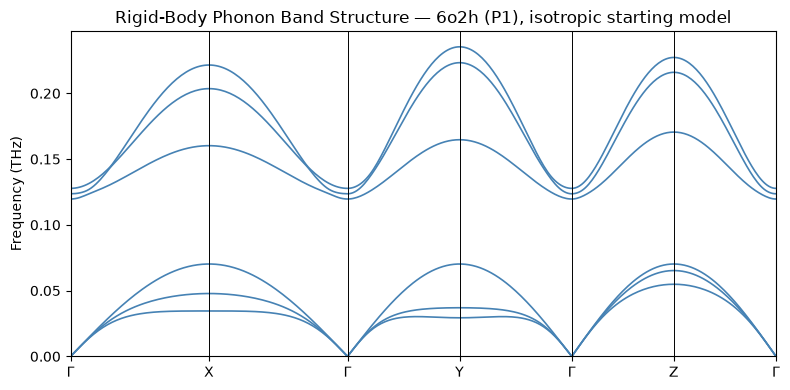

In [13]:
HSP = {'Γ':np.array([0.,0.,0.]),'X':np.array([.5,0.,0.]),
       'Y':np.array([0.,.5,0.]),'Z':np.array([0.,0.,.5])}
path_labels = ['Γ','X','Γ','Y','Γ','Z','Γ']
N_seg = 60

q_frac, tick_idx = [], [0]
for seg in range(len(path_labels)-1):
    p0, p1 = HSP[path_labels[seg]], HSP[path_labels[seg+1]]
    last = (seg == len(path_labels)-2)
    for t in np.linspace(0, 1, N_seg, endpoint=last):
        q_frac.append(p0*(1-t)+p1*t)
    if not last: tick_idx.append(len(q_frac))
tick_idx.append(len(q_frac)-1)

q_frac  = np.array(q_frac)
q_cart  = (B_recip @ q_frac.T).T
freqs_bs = []
for q in q_cart:
    D  = dynamical_matrix(q, unique, K_lab_iso)
    ev = np.linalg.eigvalsh((Msq_inv @ D @ Msq_inv.T).real)
    freqs_bs.append(np.sqrt(np.maximum(ev,0)) * freq_unit)
freqs_bs = np.array(freqs_bs)

x = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(q_cart,axis=0),axis=1))])
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(x, freqs_bs, color='steelblue', lw=1.2)
for ti in tick_idx: ax.axvline(x[ti], color='k', lw=0.7)
ax.set_xticks([x[ti] for ti in tick_idx]); ax.set_xticklabels(path_labels)
ax.set_ylabel('Frequency (THz)'); ax.set_xlim(x[0],x[-1]); ax.set_ylim(0)
ax.set_title('Rigid-Body Phonon Band Structure — 6o2h (P1), isotropic starting model')
plt.tight_layout(); plt.savefig('band_structure_isotropic.png', dpi=150); plt.show()


## Choosing a Resolution Shell From the Data

Rather than assuming a resolution cutoff, we scan the experimental map's own
signal-to-noise as a function of resolution and let the data pick the shell
used for refinement. The scan streams the map **one $h$-index slice at a
time** directly from the HDF5 file — a $(n_k\times n_l)$ plane, not the full
3-D array — so peak memory stays at the size of one slice regardless of how
large the deposited map is (585×605×341 voxels ≈ 1 GB for `I` and `sigma`
combined in the real 128 kB Å$^{-3}$-scale deposition).

For each resolution bin we track the mean intensity and mean $\sigma$ over
all *finite* voxels (a voxel is finite when it fell inside the measured
region and wasn't left as a gap-fill/interpolation placeholder — see the
README's note that `sigma = Inf` marks such voxels) and use
$\overline{I}/\overline{\sigma}$ as a coarse, streaming-friendly proxy for
SNR. The fitting shell is then the widest **contiguous** run of bins whose
proxy SNR clears a threshold and whose finite-voxel fraction is high enough
to be worth fitting, biased toward the finest (smallest-$d$) such run since
that is where the largest number of independent contact-stiffness
constraints live.


In [14]:
N_RES_BINS   = 40      # resolution bins for the SNR scan
D_SCAN_MAX   = 10.0    # Å — coarsest resolution considered (avoids the very
                       # low-order terms, which are few in number and can be
                       # dominated by long-range effects outside this model)
SNR_THRESHOLD       = 1.5
MIN_FINITE_FRACTION = 0.15

inv_d_max = 2*np.pi / 1.0   # scan bins out to 1 Å; real data rarely reaches this
inv_d_edges = np.linspace(0.0, inv_d_max, N_RES_BINS + 1)
inv_d_mid   = 0.5*(inv_d_edges[:-1] + inv_d_edges[1:])

sum_I      = np.zeros(N_RES_BINS)
sum_sigma  = np.zeros(N_RES_BINS)
cnt_finite = np.zeros(N_RES_BINS, dtype=np.int64)
cnt_total  = np.zeros(N_RES_BINS, dtype=np.int64)

nH, nK, nL = grid_size
with h5py.File(H5_FILE, 'r') as f:
    Ids = f[f'{MAP_GROUP}/I']
    Sds = f[f'{MAP_GROUP}/sigma']
    jj_idx, kk_idx = np.meshgrid(np.arange(nK), np.arange(nL), indexing='ij')
    k_frac = grid_ori[1] + jj_idx*grid_delta[1]
    l_frac = grid_ori[2] + kk_idx*grid_delta[2]
    for i in range(nH):
        h_frac = grid_ori[0] + i*grid_delta[0]
        q = (h_frac*B_recip[:,0][None,None,:] + k_frac[:,:,None]*B_recip[:,1][None,None,:]
             + l_frac[:,:,None]*B_recip[:,2][None,None,:])
        qn = np.linalg.norm(q, axis=-1)                       # (nK, nL)

        I_slice = Ids[i, :, :]
        S_slice = Sds[i, :, :]
        finite  = np.isfinite(I_slice) & np.isfinite(S_slice) & (S_slice > 0)

        bin_idx = np.clip(np.digitize(qn, inv_d_edges) - 1, 0, N_RES_BINS - 1)
        np.add.at(cnt_total, bin_idx.ravel(), 1)
        fb = bin_idx[finite]
        np.add.at(cnt_finite, fb, 1)
        np.add.at(sum_I,     fb, I_slice[finite].astype(np.float64))
        np.add.at(sum_sigma, fb, S_slice[finite].astype(np.float64))

with np.errstate(invalid='ignore', divide='ignore'):
    mean_I     = np.where(cnt_finite > 0, sum_I / np.maximum(cnt_finite, 1), np.nan)
    mean_sigma = np.where(cnt_finite > 0, sum_sigma / np.maximum(cnt_finite, 1), np.nan)
    snr_proxy  = mean_I / mean_sigma
finite_frac = cnt_finite / np.maximum(cnt_total, 1)

d_mid = np.where(inv_d_mid > 1e-6, 2*np.pi/np.maximum(inv_d_mid, 1e-6), np.inf)

print(f"Scanned {nH} h-index slices of '/{MAP_GROUP}' "
      f"({cnt_finite.sum()} finite voxels total).")


Scanned 341 h-index slices of '/maps/processed/variational' (43866426 finite voxels total).


Trimmed the widest qualifying run from 2.05-6.15 Å down to 2.00-2.11 Å (≈1561569 finite voxels) to keep the candidate pool bounded.
Note: the single finest-resolution bin in this run already contains 1561569 finite voxels, more than TARGET_POOL_SIZE -- the selected shell can't be narrower than one bin (2.00-2.11 Å) without increasing N_RES_BINS. This is fine as long as the (vectorized) conditioning screen below stays fast.
Automatically selected fitting shell: 2.00-2.11 Å resolution


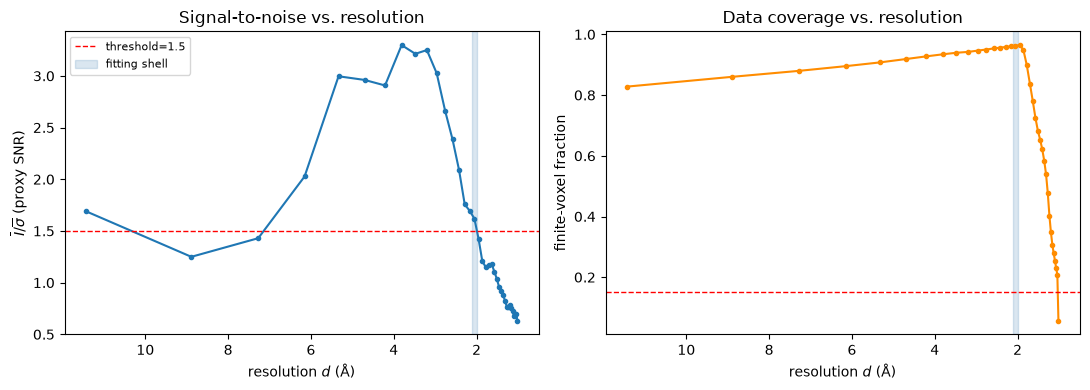

In [15]:
# Contiguous runs of "good" bins (by SNR proxy and finite coverage),
# restricted to d <= D_SCAN_MAX. A resolution shell is an annulus in 3D
# q-space, so its voxel count grows very fast with width (roughly as the
# shell's volume) -- picking the WIDEST qualifying run, as an earlier
# version of this cell did, can select a shell with many millions of
# candidate voxels even though only a few thousand are ever used (after
# subsampling to N_FIT_MAX), making the "well-conditioned" screen below far
# slower than it needs to be. Instead: take the best (longest) qualifying
# run as a starting point, then walk inward from its finest-resolution edge
# and stop as soon as the *cumulative finite-voxel count* reaches
# TARGET_POOL_SIZE -- enough for a healthy random subsample, not an
# unbounded scan of the whole shell.
good = (snr_proxy > SNR_THRESHOLD) & (finite_frac > MIN_FINITE_FRACTION) & (d_mid <= D_SCAN_MAX)

runs = []
start = None
for i, g in enumerate(good):
    if g and start is None:
        start = i
    elif not g and start is not None:
        runs.append((start, i-1)); start = None
if start is not None:
    runs.append((start, len(good)-1))

TARGET_POOL_SIZE = 50 * N_FIT_MAX   # aim to gather roughly this many candidate
                                    # voxels before subsampling to N_FIT_MAX --
                                    # comfortably more than needed, but nowhere
                                    # near the size of the whole shell

if runs:
    # NOTE: bins are indexed by increasing inv_d (~q), so d_mid *decreases*
    # as the bin index increases -- within a run (lo, hi), "lo" (the
    # smaller index) is the COARSE (large-d) end and "hi" is the FINE
    # (small-d) end. The walk below must therefore start at hi and move
    # toward lo, keeping the fine edge fixed and trimming only the coarse
    # edge inward.
    best = max(runs, key=lambda r: (r[1]-r[0], r[1]))   # longest run, ties -> finer resolution (larger hi)
    lo, hi = best
    cum, trim_lo = 0, hi
    for i in range(hi, lo-1, -1):       # walk from the finest-resolution edge (hi) toward coarser (lo)
        cum += cnt_finite[i]
        trim_lo = i
        if cum >= TARGET_POOL_SIZE:
            break
    # Report the shell using the bins' actual EDGES, not their centers
    # (d_mid). A resolution bin's voxel count grows with q (roughly as the
    # shell's volume, ~q^2), so on real data a single fine-resolution bin
    # can easily exceed TARGET_POOL_SIZE on its own -- the walk above then
    # stops after including just that one bin. Using d_mid for both
    # boundaries would report that as a zero-width "shell" (d_mid[hi] to
    # d_mid[hi]), even though the bin itself spans a real, nonzero range of
    # d; using the bin's edges instead reports its true (nonzero) width.
    inv_d_fine_edge   = inv_d_edges[hi + 1]     # finer boundary of the finest included bin
    inv_d_coarse_edge = inv_d_edges[trim_lo]    # coarser boundary of the coarsest included bin
    D_FIT_MIN = float(2*np.pi/inv_d_fine_edge) if inv_d_fine_edge > 1e-6 else 0.0
    D_FIT_MAX = float(2*np.pi/inv_d_coarse_edge) if inv_d_coarse_edge > 1e-6 else D_SCAN_MAX
    if trim_lo > lo:
        print(f"Trimmed the widest qualifying run from {float(d_mid[hi]):.2f}-{float(d_mid[lo]):.2f} Å "
              f"down to {D_FIT_MIN:.2f}-{D_FIT_MAX:.2f} Å (≈{cum} finite voxels) to keep the "
              f"candidate pool bounded.")
    if trim_lo == hi and cnt_finite[hi] > TARGET_POOL_SIZE:
        print(f"Note: the single finest-resolution bin in this run already contains "
              f"{cnt_finite[hi]} finite voxels, more than TARGET_POOL_SIZE -- the "
              f"selected shell can't be narrower than one bin ({D_FIT_MIN:.2f}-{D_FIT_MAX:.2f} Å) "
              f"without increasing N_RES_BINS. This is fine as long as the "
              f"(vectorized) conditioning screen below stays fast.")
else:
    print("No resolution bin cleared the SNR/coverage thresholds; "
          "falling back to the literature shell (2.0-2.5 Å) used in the "
          "original publication for this dataset.")
    D_FIT_MIN, D_FIT_MAX = 2.0, 2.5

print(f"Automatically selected fitting shell: {D_FIT_MIN:.2f}-{D_FIT_MAX:.2f} Å resolution")

fig, axes = plt.subplots(1, 2, figsize=(11,4))
finite_d = np.isfinite(d_mid) & (d_mid <= D_SCAN_MAX*1.5)
axes[0].plot(d_mid[finite_d], snr_proxy[finite_d], 'o-', ms=3)
axes[0].axhline(SNR_THRESHOLD, color='r', ls='--', lw=1, label=f'threshold={SNR_THRESHOLD}')
axes[0].axvspan(D_FIT_MIN, D_FIT_MAX, color='steelblue', alpha=0.2, label='fitting shell')
axes[0].set_xlabel('resolution $d$ (Å)'); axes[0].set_ylabel(r'$\overline{I}/\overline{\sigma}$ (proxy SNR)')
axes[0].invert_xaxis(); axes[0].legend(fontsize=8); axes[0].set_title('Signal-to-noise vs. resolution')

axes[1].plot(d_mid[finite_d], finite_frac[finite_d], 'o-', ms=3, color='darkorange')
axes[1].axhline(MIN_FINITE_FRACTION, color='r', ls='--', lw=1)
axes[1].axvspan(D_FIT_MIN, D_FIT_MAX, color='steelblue', alpha=0.2)
axes[1].set_xlabel('resolution $d$ (Å)'); axes[1].set_ylabel('finite-voxel fraction')
axes[1].invert_xaxis(); axes[1].set_title('Data coverage vs. resolution')

plt.tight_layout(); plt.savefig('resolution_snr_scan.png', dpi=150); plt.show()


## Experimental Diffuse-Scattering Data

Within the automatically chosen resolution shell, every finite voxel is a
candidate training point: this second streaming pass (again one $h$-slice at
a time, so memory is unaffected by the map's total size) collects
$(h,k,l,I_{\rm obs},\sigma)$ for voxels that (a) fall in the shell, (b) have
finite, positive $\sigma$, and (c) are not suspiciously close to an integer
Miller index — a cheap extra safety margin on top of whatever Bragg-peak
masking the deposited map already applied. The candidate pool is then
randomly subsampled down to `N_FIT_MAX` points (inverse-variance weighted,
same as the rest of the refinement) and split into training and held-out
($R_{\rm free}$) sets.


In [16]:
def collect_experimental_qpoints(d_lo, d_hi, bragg_excl=BRAGG_EXCLUSION):
    """Also returns, per collected voxel, its Cartesian distance (Å^-1) to
    the NEAREST reciprocal-lattice point ('bragg_dist') -- a purely
    geometric quantity that depends only on (h,k,l), never on I_obs or its
    sign. This is what a halo-vs-away-from-halo reliability weighting
    should be built on (see the fitting-weight cell below): selecting or
    down-weighting points based on where they sit in q-space introduces no
    bias, whereas selecting/excluding them based on the sign of the noisy
    I_obs value they happen to carry would (see markdown discussion)."""
    hs, ks, ls, Is, Ss, Bds = [], [], [], [], [], []
    q_lo, q_hi = 2*np.pi/d_hi, 2*np.pi/d_lo    # d_hi (coarser) -> smaller |q|
    with h5py.File(H5_FILE, 'r') as f:
        Ids = f[f'{MAP_GROUP}/I']
        Sds = f[f'{MAP_GROUP}/sigma']
        jj_idx, kk_idx = np.meshgrid(np.arange(nK), np.arange(nL), indexing='ij')
        k_frac_all = grid_ori[1] + jj_idx*grid_delta[1]
        l_frac_all = grid_ori[2] + kk_idx*grid_delta[2]
        dk_all = k_frac_all - np.round(k_frac_all)     # signed offset from nearest integer k
        dl_all = l_frac_all - np.round(l_frac_all)     # signed offset from nearest integer l
        for i in range(nH):
            h_frac = grid_ori[0] + i*grid_delta[0]
            dh = h_frac - round(h_frac)                # signed offset from nearest integer h
            if abs(dh) < bragg_excl:
                near_h_bragg = True
            else:
                near_h_bragg = False
            q = (h_frac*B_recip[:,0][None,None,:] + k_frac_all[:,:,None]*B_recip[:,1][None,None,:]
                 + l_frac_all[:,:,None]*B_recip[:,2][None,None,:])
            qn = np.linalg.norm(q, axis=-1)
            in_shell = (qn >= q_lo) & (qn <= q_hi)
            if not in_shell.any():
                continue
            I_slice = Ids[i, :, :]; S_slice = Sds[i, :, :]
            ok = in_shell & np.isfinite(I_slice) & np.isfinite(S_slice) & (S_slice > 0)
            if near_h_bragg:
                ok &= False   # whole plane is Bragg-adjacent in h; skip entirely
            else:
                dk = np.abs(dk_all); dl = np.abs(dl_all)
                ok &= ~((dk < bragg_excl) & (dl < bragg_excl))
            sel = np.where(ok)
            if len(sel[0]) == 0:
                continue
            # Cartesian offset from the nearest reciprocal-lattice point --
            # a geometric distance, independent of the measured I/sigma.
            dq_bragg = (dh*B_recip[:,0][None] + dk_all[sel][:,None]*B_recip[:,1][None]
                        + dl_all[sel][:,None]*B_recip[:,2][None])
            hs.append(np.full(len(sel[0]), h_frac))
            ks.append(k_frac_all[sel]); ls.append(l_frac_all[sel])
            Is.append(I_slice[sel].astype(np.float64)); Ss.append(S_slice[sel].astype(np.float64))
            Bds.append(np.linalg.norm(dq_bragg, axis=-1))
    if not hs:
        return np.zeros((0,3)), np.zeros(0), np.zeros(0), np.zeros(0)
    hkl = np.column_stack([np.concatenate(hs), np.concatenate(ks), np.concatenate(ls)])
    return hkl, np.concatenate(Is), np.concatenate(Ss), np.concatenate(Bds)

hkl_pool, I_pool, sigma_pool, bragg_dist_pool = collect_experimental_qpoints(D_FIT_MIN, D_FIT_MAX)
print(f"{len(hkl_pool)} candidate voxels in the {D_FIT_MIN:.2f}-{D_FIT_MAX:.2f} Å shell "
      f"(before conditioning screen / subsampling)")


1409367 candidate voxels in the 2.00-2.11 Å shell (before conditioning screen / subsampling)


### Is the Negative-Intensity Pattern Really Halo-Related?

Before deciding how (or whether) to down-weight voxels far from a Bragg
position, check the premise directly: bin the candidate pool by
`bragg_dist` (Cartesian distance to the nearest reciprocal-lattice point,
computed purely from $(h,k,l)$ -- it knows nothing about the measured
$I_{\rm obs}$ or its sign) and look at how the negative fraction and mean
$I_{\rm obs}$ actually vary with it. If the pattern described -- negative
values concentrated away from the halos -- holds up here, that supports
treating `bragg_dist` as a *reliability* covariate; if it doesn't, a
distance-based weighting would be fixing the wrong thing.


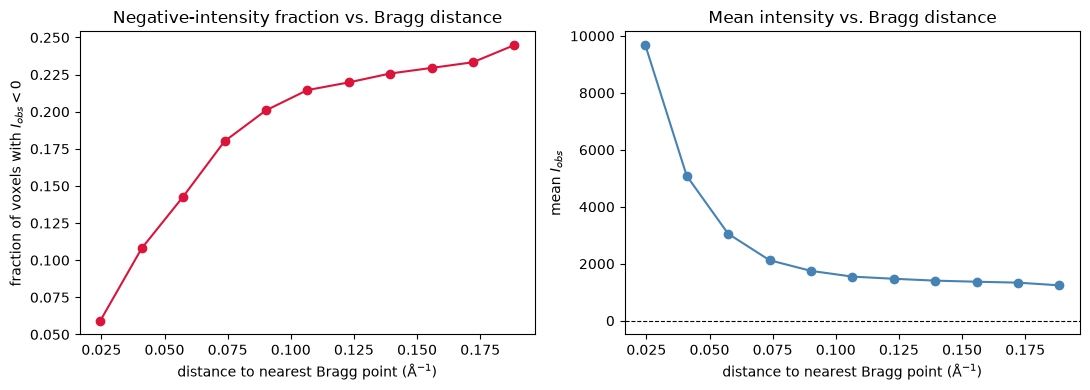

Overall negative fraction in the candidate pool: 20.4%


In [17]:
if len(bragg_dist_pool):
    nbins = 12
    bd_edges = np.linspace(0, np.percentile(bragg_dist_pool, 99), nbins+1)
    bd_mid   = 0.5*(bd_edges[:-1]+bd_edges[1:])
    bd_idx   = np.clip(np.digitize(bragg_dist_pool, bd_edges)-1, 0, nbins-1)
    neg_frac = np.array([(I_pool[bd_idx==b] < 0).mean() if (bd_idx==b).any() else np.nan for b in range(nbins)])
    mean_I   = np.array([I_pool[bd_idx==b].mean()        if (bd_idx==b).any() else np.nan for b in range(nbins)])

    fig, axes = plt.subplots(1, 2, figsize=(11,4))
    axes[0].plot(bd_mid, neg_frac, 'o-', color='crimson')
    axes[0].set_xlabel(r'distance to nearest Bragg point (Å$^{-1}$)')
    axes[0].set_ylabel('fraction of voxels with $I_{obs}<0$')
    axes[0].set_title('Negative-intensity fraction vs. Bragg distance')
    axes[1].plot(bd_mid, mean_I, 'o-', color='steelblue')
    axes[1].axhline(0, color='k', lw=0.8, ls='--')
    axes[1].set_xlabel(r'distance to nearest Bragg point (Å$^{-1}$)')
    axes[1].set_ylabel(r'mean $I_{obs}$')
    axes[1].set_title('Mean intensity vs. Bragg distance')
    plt.tight_layout(); plt.savefig('bragg_distance_diagnostic.png', dpi=150); plt.show()
    print(f"Overall negative fraction in the candidate pool: {(I_pool<0).mean():.1%}")
else:
    print("No candidate voxels to diagnose.")


In [18]:
def well_conditioned(K_lab, h, k, l, min_eig_frac=1e-4):
    """D(q) is only ever exactly singular at reciprocal-lattice points; a
    few q-points can still land close enough to a near-degenerate direction
    that the plain (non-pseudo-inverse) solve used during refinement is
    ill-conditioned, so those are screened out here rather than included in
    a fit that assumes a smooth, invertible D(q)."""
    q = h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2]
    D = dynamical_matrix(q, unique, K_lab)
    ev = np.linalg.eigvalsh(D.real)
    return ev.max() > 0 and ev.min()/ev.max() > min_eig_frac

def well_conditioned_batch(K_lab, h_arr, k_arr, l_arr, min_eig_frac=1e-4, chunk=None):
    """Vectorized/chunked version of well_conditioned, using the existing
    dynamical_matrix_batch instead of a per-point Python loop + eigvalsh --
    the candidate pool here can run into the millions of voxels (a whole
    resolution shell before subsampling to N_FIT_MAX), so a serial loop is
    the dominant cost otherwise."""
    chunk = chunk or CHUNK_EVAL
    h_arr = np.asarray(h_arr, dtype=float); k_arr = np.asarray(k_arr, dtype=float)
    l_arr = np.asarray(l_arr, dtype=float)
    N = len(h_arr)
    keep_out = np.zeros(N, dtype=bool)
    for s in range(0, N, chunk):
        sl = slice(s, min(s+chunk, N))
        qb = (h_arr[sl,None]*B_recip[:,0][None,:] + k_arr[sl,None]*B_recip[:,1][None,:]
              + l_arr[sl,None]*B_recip[:,2][None,:])
        Db = dynamical_matrix_batch(qb, unique, K_lab)
        ev = np.linalg.eigvalsh(Db.real)                      # (n,6), ascending
        emax = ev[:, -1]
        emin = ev[:, 0]
        keep_out[sl] = (emax > 0) & (emin / np.where(emax > 0, emax, 1.0) > min_eig_frac)
    return keep_out

rng = np.random.default_rng(7)
n_pool = len(hkl_pool)
keep = (well_conditioned_batch(K_lab_iso, hkl_pool[:,0], hkl_pool[:,1], hkl_pool[:,2])
        if n_pool else np.zeros(0, bool))
hkl_pool, I_pool, sigma_pool, bragg_dist_pool = (hkl_pool[keep], I_pool[keep],
                                                  sigma_pool[keep], bragg_dist_pool[keep])
print(f"{keep.sum()}/{n_pool} kept after the conditioning screen")

n_use = min(N_FIT_MAX, len(hkl_pool))
sub_idx = rng.choice(len(hkl_pool), size=n_use, replace=False)
hkl_use, I_use, sigma_use, bragg_dist_use = (hkl_pool[sub_idx], I_pool[sub_idx],
                                              sigma_pool[sub_idx], bragg_dist_pool[sub_idx])

train_mask = rng.random(n_use) > HOLDOUT_FRAC
q_train, I_train, sigma_train, bragg_dist_train = (hkl_use[train_mask], I_use[train_mask],
                                                    sigma_use[train_mask], bragg_dist_use[train_mask])
q_test,  I_test,  sigma_test,  bragg_dist_test  = (hkl_use[~train_mask], I_use[~train_mask],
                                                    sigma_use[~train_mask], bragg_dist_use[~train_mask])

print(f"{n_use} q-points used: {train_mask.sum()} training, "
      f"{(~train_mask).sum()} held out for R_free")


1409367/1409367 kept after the conditioning screen
1500 q-points used: 1292 training, 208 held out for R_free


### Weighting by Distance From the Halo, Not by the Sign of $I_{\rm obs}$

It's tempting to simply drop training points with $I_{\rm obs}<0$, since
$I_{\rm model}=G^\dagger D^{-1}G$ is a Hermitian quadratic form and can
*never* be negative -- no fit can match a negative target exactly. But
filtering on the **sign of the very quantity being fit** is a form of
selection bias: if the true (non-negative) signal is small in some region
and noise is roughly symmetric, keeping only the voxels where noise pushed
$I_{\rm obs}$ above zero -- while discarding the equally-informative voxels
where the same noise pushed it below zero -- systematically inflates the
retained sample's mean above the true value. It would also mechanically
improve the reported $R$/$R_{\rm free}$ without the fit actually being any
more accurate, since exactly the points guaranteed to contribute a large
residual are the ones being removed.

The distance to the nearest Bragg peak (`bragg_dist`, computed purely from
$(h,k,l)$, above) is a legitimate, unbiased alternative: it's a property of
*where a point sits in q-space*, not of what its noisy measurement happens
to be, so down-weighting by it doesn't selectively discard one side of the
noise distribution. `HALO_LENGTHSCALE` sets how quickly a point's fitting
weight decays with distance from the nearest Bragg peak, as a Gaussian in
`bragg_dist`: leave it at `np.inf` to fit the whole selected shell uniformly
(current default -- no change in behavior), lower it to smoothly favor
near-Bragg ("halo") points the way earlier acoustic-only studies of this
kind of data implicitly did, or pick an intermediate value to blend in some
off-halo, higher-order (optical-mode-sensitive) information while still
discounting the region where background subtraction looks least reliable
(check the diagnostic plot above first to see whether/where that's
warranted for this dataset).


In [19]:
HALO_LENGTHSCALE = 0.05     # Å^-1; np.inf = uniform weighting (no halo preference).
                            # Lower values smoothly favor points near a Bragg peak;
                            # tune against the bragg_dist diagnostic above.

halo_factor_train = np.exp(-(bragg_dist_train / HALO_LENGTHSCALE)**2) if np.isfinite(HALO_LENGTHSCALE) else np.ones(len(bragg_dist_train))
w_train = (1.0 / sigma_train**2) * halo_factor_train

if np.isfinite(HALO_LENGTHSCALE):
    print(f"HALO_LENGTHSCALE={HALO_LENGTHSCALE:.3f} Å⁻¹: halo weighting active "
          f"(median weight retained: {np.median(halo_factor_train):.3f} of inverse-variance weight)")
else:
    print("HALO_LENGTHSCALE=inf: no halo-distance weighting -- every point in the "
          "selected shell contributes by inverse-variance weight alone (unchanged from before).")


HALO_LENGTHSCALE=0.050 Å⁻¹: halo weighting active (median weight retained: 0.011 of inverse-variance weight)


$G(\mathbf q)$ depends only on the structure and $\mathbf q$, never on the
contact stiffnesses being fit, so it is computed **once** for the training
and held-out sets here (via the batched, memory-bounded evaluator above)
rather than recomputed from scratch at every refinement iteration — with
L-BFGS-B typically taking a few hundred iterations, that turns thousands of
redundant Fourier-sum evaluations into one.


In [20]:
G_train = G_at_hkl_batch(q_train[:,0], q_train[:,1], q_train[:,2]) if len(q_train) else np.zeros((0,6), complex)
G_test  = G_at_hkl_batch(q_test[:,0],  q_test[:,1],  q_test[:,2])  if len(q_test)  else np.zeros((0,6), complex)
print(f"Cached G(q) for {len(G_train)} training and {len(G_test)} held-out points")


Cached G(q) for 1292 training and 208 held-out points


In [21]:
def forward_I(K_lab, h, k, l, G=None):
    q = h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2]
    if G is None:
        G = G_at_hkl(h, k, l)
    D = dynamical_matrix(q, unique, K_lab)
    v = np.linalg.solve(D, G)
    return float(np.real(np.conj(G) @ v))


## Where the Fitted q-Points Sit

The sampled points span a range of Miller-index $l$ layers, so they are not
coplanar in $\mathbf q$-space; the left panel shows all of them in true
Cartesian $\mathbf q$ (Å$^{-1}$). The two right panels overlay the training
and held-out points on the **actual experimental map** at $l=0$ and
$l\approx0.5$ (single 2-D slices read directly from the HDF5 file — cheap,
regardless of the full map's size), so the sampled shell is visible relative
to where the real diffuse signal actually is.


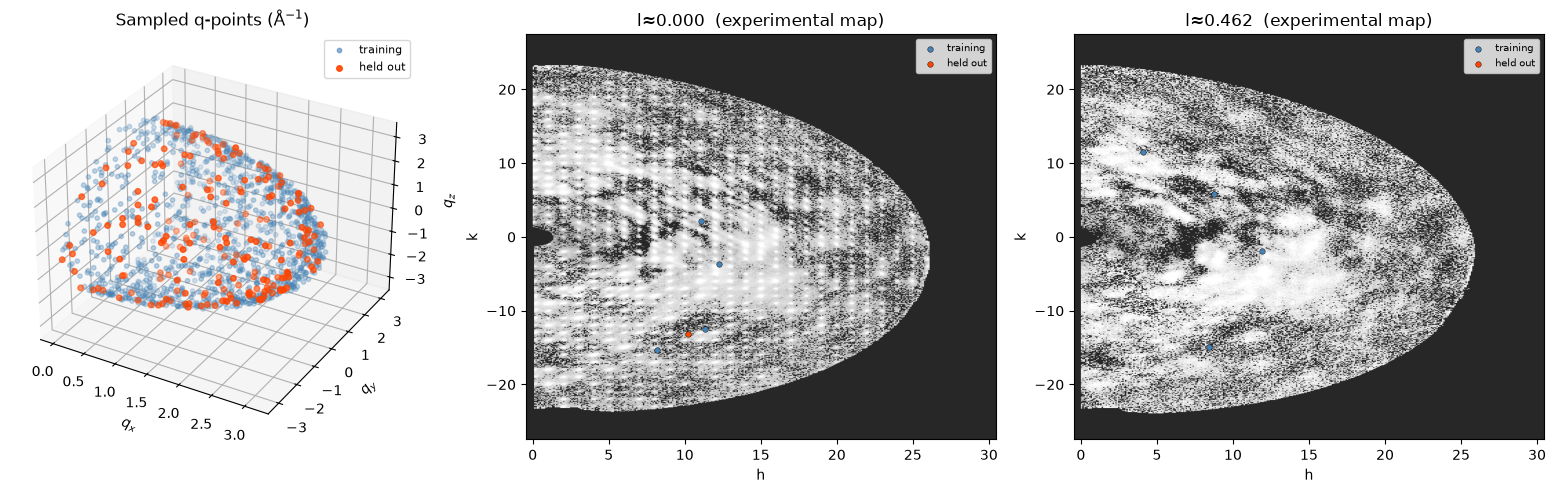

4 training points near l=0.000, 4 near l=0.462


In [22]:
def nearest_l_index(l_target):
    return int(round((l_target - grid_ori[2]) / grid_delta[2]))

def read_hk_plane(l_index):
    with h5py.File(H5_FILE, 'r') as f:
        I_plane = f[f'{MAP_GROUP}/I'][:, :, l_index]
    h_pts = grid_ori[0] + np.arange(nH)*grid_delta[0]
    k_pts = grid_ori[1] + np.arange(nK)*grid_delta[1]
    return h_pts, k_pts, np.asarray(I_plane)

l_idx_0   = nearest_l_index(0.0)
l_idx_half = nearest_l_index(0.5)
h_pts_bg0,  k_pts_bg0,  I_bg0  = read_hk_plane(l_idx_0)
h_pts_bg05, k_pts_bg05, I_bg05 = read_hk_plane(l_idx_half)
l_layer_0  = grid_ori[2] + l_idx_0*grid_delta[2]
l_layer_05 = grid_ori[2] + l_idx_half*grid_delta[2]

def q_cart_of(pts):
    return np.array([h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2] for h,k,l in pts])

qc_train, qc_test = q_cart_of(q_train), q_cart_of(q_test)

fig = plt.figure(figsize=(16, 5))
ax3d = fig.add_subplot(1, 3, 1, projection='3d')
ax3d.scatter(*qc_train.T, s=10, alpha=0.6, color='steelblue', label='training')
ax3d.scatter(*qc_test.T,  s=16, alpha=0.9, color='orangered', label='held out')
ax3d.set_xlabel('$q_x$'); ax3d.set_ylabel('$q_y$'); ax3d.set_zlabel('$q_z$')
ax3d.set_title('Sampled q-points (Å$^{-1}$)'); ax3d.legend(fontsize=8)

def overlay_panel(ax, h_pts, k_pts, I_bg, l_layer):
    pos = I_bg[np.isfinite(I_bg) & (I_bg > 0)]
    vmax = np.percentile(pos, 97) if len(pos) else 1.0
    I_disp = np.log1p(np.clip(np.nan_to_num(I_bg, nan=0.0), 0, vmax)) / np.log(10)
    ax.imshow(I_disp.T, origin='lower', cmap='gray',
              extent=[h_pts[0], h_pts[-1], k_pts[0], k_pts[-1]], aspect='auto', alpha=0.85)
    for pts, color, label in [(q_train, 'steelblue', 'training'), (q_test, 'orangered', 'held out')]:
        sel = np.abs(pts[:,2] - l_layer) < 0.5*grid_delta[2]
        ax.scatter(pts[sel,0], pts[sel,1], s=16, color=color, edgecolor='k',
                  linewidth=0.3, label=label)
    ax.set_xlabel('h'); ax.set_ylabel('k'); ax.set_title(f'l≈{l_layer:.3f}  (experimental map)')
    ax.legend(fontsize=7, loc='upper right')

overlay_panel(fig.add_subplot(1,3,2), h_pts_bg0,  k_pts_bg0,  I_bg0,  l_layer_0)
overlay_panel(fig.add_subplot(1,3,3), h_pts_bg05, k_pts_bg05, I_bg05, l_layer_05)

plt.tight_layout(); plt.savefig('sampled_q_points.png', dpi=150); plt.show()
print(f"{(np.abs(q_train[:,2]-l_layer_0)<0.5*grid_delta[2]).sum()} training points near l={l_layer_0:.3f}, "
      f"{(np.abs(q_train[:,2]-l_layer_05)<0.5*grid_delta[2]).sum()} near l={l_layer_05:.3f}")


## Refining $K$ to the Experimental Data

The objective is a weighted least-squares fit plus the local-frame
regularizer, minimized over the Cholesky factors $\{L_{\mathbf n}\}$:

$$\mathcal L(\theta) = \sum_{\mathbf q\in\rm train} w(\mathbf q)
\bigl[I_{\rm obs}(\mathbf q)-I_{\rm model}(\mathbf q;\theta)\bigr]^2
+ \lambda\sum_{\mathbf n}\bigl\|K_{\mathbf n}^{\rm local}[\Omega,v]\bigr\|_F^2$$

with $w(\mathbf q)=1/\sigma_{\rm exp}(\mathbf q)^2$ taken directly from the
deposited map's own per-voxel error estimate — no noise model is assumed or
injected, unlike a synthetic-data test.

**Overall intensity scale.** $I_{\rm model}=G^\dagger D^{-1}G$ is computed in
this notebook's own absolute units (electron density × thermal-normalization
convention), which need not coincide with the deposited map's own absolute
normalization from its independent data-reduction pipeline. Since $D$ (hence
$I_{\rm model}$) is *linear* in $K$, a uniform rescaling $K\to\lambda K$
rescales $I_{\rm model}\to I_{\rm model}/\lambda$ exactly — and the
predicted ADPs/B-factors (also built from $D^{-1}$) rescale the *same* way —
so a pure scale mismatch and a genuine stiffness error are, from the diffuse
data alone, perfectly degenerate: no amount of diffuse-map fitting can ever
tell them apart.

An earlier version of this cell tried to resolve that by *freely
re-profiling* an overall scale $s^\star=\arg\min_s\sum w(s\,I_{\rm
model}-I_{\rm obs})^2$ at every evaluation (closed-form weighted least
squares, valid via the envelope theorem — this remains available as
`loss_and_grad(..., s_fixed=None)` and as the standalone `profiled_scale`
helper below). That is mathematically consistent but has a real practical
failure mode: letting $s$ re-adapt to whatever $K$ currently is makes the
*data* loss **exactly invariant** to the overall magnitude of $K$ (verified
directly: rescaling $K$ by any factor and re-profiling $s$ reproduces the
identical loss to machine precision), leaving that direction controlled
*only* by the regularizer — which strictly prefers smaller $K$ (softer
contacts). With nothing else to hold it back, refinement can run away along
that direction toward implausibly soft $K$ (arbitrarily large predicted
B-factors) exactly as readily as, without any scale correction at all, it
previously ran away toward implausibly stiff $K$ — same underlying
degeneracy, opposite failure mode.

The fix used here instead: compute a scale **once**, from a fixed reference
$K$ (the isotropic starting guess, before any refinement), and hold it
**fixed** throughout the L-BFGS-B run via `s_fixed`. With $s$ no longer
free to co-adapt with $K$, rescaling $K$ during optimization changes the
data loss again, so the regularizer is back to being a mild bias rather
than the sole determinant of $K$'s absolute scale. This one-time scale
still corrects for the bulk of the real units mismatch (it's fit from the
actual data, just not re-fit every iteration), and after refinement
converges, one more calibration step rescales the *fitted* $K$ (and
correspondingly its scale) so the predicted mean isotropic B-factor exactly
matches the deposited mean — using the one piece of information the
diffuse map alone can never supply: an independent, Bragg-derived
measurement of the true absolute displacement scale. This final rescaling
changes no diffuse-intensity prediction whatsoever (the fitted $K$'s
*shape* — its relative structure across contacts, anisotropy, mode
character — is set entirely by the diffuse data and is untouched by it), so
$R$/$R_{\rm free}$ are unaffected; it only fixes the otherwise-arbitrary
split between "how stiff is $K$, numerically" and "what the intensity
scale is," which the diffuse data alone cannot resolve.

**Gradient.** Since $I=G^\dagger D^{-1}G$ and $d(D^{-1})=-D^{-1}\,dD\,D^{-1}$,
$dI = -v^\dagger\,dD\,v$ with $v=D^{-1}G$. Because $D$ is linear in each
contact's $K_{\mathbf n}$, $dD$ is a known linear function of $dK_{\mathbf n}$,
giving a closed-form $dI/dK_{\mathbf n}$ at essentially no extra cost beyond
the forward evaluation; the chain rule through the fixed lab-frame transform
and the Cholesky factor $K=LL^{\mathsf T}$ then gives $d\mathcal L/dL$
directly (verified below against finite differences).

**Optimizer.** L-BFGS-B with the analytic gradient above. The Cholesky
parameterization makes every point in parameter space a physically stable
model (Section above), so the optimizer runs unconstrained over
$\mathbb R^{N_{\rm params}}$ rather than needing inequality constraints on
$K$; with exact gradients in hand, a quasi-Newton method converges in far
fewer iterations than a derivative-free or finite-difference approach would
need, and no global/stochastic search (basin-hopping, CMA-ES) is warranted
for a smooth, unconstrained, well-conditioned objective like this one. The
training q-points passed the conditioning screen above, so $D(\mathbf q)$ is
comfortably invertible there and a plain solve (rather than the diffuse-
map's pseudo-inverse) is used, keeping the objective smooth. A generous box
bound `L_BOUND` is placed on each Cholesky entry — L-BFGS-B accepts bounds
natively — purely as a safety rail: since larger $K$ monotonically *reduces*
$I(\mathbf q)$ (stiffer contacts damp the fluctuations that produce diffuse
scattering), a resolution shell with a weak or noise-dominated signal can
otherwise let the optimizer run away toward arbitrarily stiff, physically
meaningless contacts instead of settling near a genuine optimum; the bound
is far outside the range any physically reasonable contact stiffness should
occupy, so it never competes with the data once the fit is behaving well.


In [23]:
def loss_and_grad(theta, q_list, G_list, I_obs, weights, s_fixed=None):
    """G_list is G(q) precomputed once for q_list (see above) -- it does
    not depend on theta/K, so recomputing it inside this function (which
    L-BFGS-B calls every iteration) would repeat the same Fourier sums
    hundreds of times for no reason.

    Vectorized over the whole point batch (dynamical_matrix_batch + a
    batched linear solve + batched per-contact gradient assembly) rather
    than looping over each training point (and, inside that, every contact)
    in Python -- with L-BFGS-B calling this once per iteration and easily
    running into the thousands of iterations on real data, an unvectorized
    version here dominates the total runtime.

    s_fixed: if given, the overall intensity scale is held at this FIXED
    value rather than re-profiled every call (see the markdown right before
    the minimize() call for why this matters -- freely re-profiling s at
    every iteration makes the data loss exactly invariant to the OVERALL
    magnitude of K, an unconstrained direction the regularizer alone then
    has to control, which can run away to a degenerate, unphysical
    solution; fixing s removes that direction entirely, restoring genuine
    data pressure on K's absolute magnitude for the whole optimization)."""
    Lmap = theta_to_Lmap(theta)
    K_local, K_lab = build_K(Lmap)

    Gamma_full = {c: np.block([[unique[c]['R_frame'], np.zeros((3,3))],
                               [np.zeros((3,3)), unique[c]['R_frame']]])
                  for c in shell_order}
    N_mat = {c: Gc_inv_matrix(unique[c]['c_local']) @ Gamma_full[c].T
             for c in shell_order}

    N = len(q_list)
    if N == 0:
        data_loss, coeff = 0.0, np.zeros(0)
        q_batch = np.zeros((0,3))
    else:
        q_list = np.asarray(q_list, dtype=float)
        q_batch = (q_list[:,0:1]*B_recip[:,0][None,:] + q_list[:,1:2]*B_recip[:,1][None,:]
                   + q_list[:,2:3]*B_recip[:,2][None,:])                 # (N,3)
        D_batch = dynamical_matrix_batch(q_batch, unique, K_lab)         # (N,6,6)
        G_arr = np.asarray(G_list)
        # np.linalg.solve needs an explicit trailing right-hand-side axis to
        # batch correctly over N systems -- b shaped plain (N,6) is instead
        # read as a single (N,6) matrix rather than N stacked vectors.
        V = np.linalg.solve(D_batch, G_arr[:, :, None])[:, :, 0]         # (N,6) batched solve
        Imodel_raw = np.real(np.sum(np.conj(G_arr) * V, axis=1))         # (N,)
        I_obs = np.asarray(I_obs); weights = np.asarray(weights)

        if s_fixed is None:
            # Profile s freely (see the s_fixed docstring note above for why
            # this alone is NOT what's used for the main refinement below).
            denom = np.sum(weights * Imodel_raw**2)
            s_used = float(np.sum(weights * Imodel_raw * I_obs) / denom) if denom > 0 else 1.0
        else:
            s_used = s_fixed   # constant w.r.t. K -- ordinary chain rule, no envelope-theorem term needed

        Imodel = s_used * Imodel_raw
        resid = Imodel - I_obs
        data_loss = float(np.sum(weights * resid**2))
        coeff = 2.0 * weights * resid * s_used                          # (N,) -- d(Imodel)/dK = s_used * d(Imodel_raw)/dK

    grad_L = {}
    for c in shell_order:
        R_n = unique[c]['R_n']
        A_n = ad_translation(R_n)
        if N == 0:
            grad_L[c] = np.zeros((6,6))
            continue
        phase = np.exp(1j * (q_batch @ R_n))          # (N,)
        pn, pneg = phase, phase.conj()
        U  = V @ A_n.T                                 # (N,6): A_n @ v, per point
        w1 = U - pn[:, None]*V
        w2 = V - pneg[:, None]*U
        Graw = -(np.einsum('ni,nj->nij', U.conj(), w1) + np.einsum('ni,nj->nij', V.conj(), w2))
        G_A  = np.einsum('ij,njk,lk->nil', N_mat[c], Graw, N_mat[c])
        dL_c = np.real(np.einsum('nij,jk->nik', (G_A + G_A.transpose(0,2,1)), Lmap[c]))
        grad_L[c] = np.einsum('n,nij->ij', coeff, dL_c)

    reg = regularizer(K_local)
    for c in shell_order:
        TR = K_local[c][0:3, 3:6]
        Graw_reg = np.zeros((6,6)); Graw_reg[0:3, 3:6] = 2*LAMBDA_REG*TR
        grad_L[c] += (Graw_reg + Graw_reg.T) @ Lmap[c]
        grad_L[c] = np.tril(grad_L[c])

    return data_loss + reg, Lmap_to_theta(grad_L)

def profiled_scale(K_lab, q_list, G_list, I_obs, weights):
    """The same weighted-least-squares scale s* used internally by
    loss_and_grad, exposed standalone so it can be recomputed once from a
    FIXED K after refinement (e.g. K_LAB_FIT) for reporting/plotting --
    always from the training set, never from the held-out set, so R_free
    stays an honest out-of-sample check rather than one that gets to
    re-optimize its own normalization."""
    N = len(q_list)
    if N == 0:
        return 1.0
    q_list = np.asarray(q_list, dtype=float)
    q_batch = (q_list[:,0:1]*B_recip[:,0][None,:] + q_list[:,1:2]*B_recip[:,1][None,:]
               + q_list[:,2:3]*B_recip[:,2][None,:])
    D_batch = dynamical_matrix_batch(q_batch, unique, K_lab)
    G_arr = np.asarray(G_list)
    V = np.linalg.solve(D_batch, G_arr[:, :, None])[:, :, 0]
    Imodel_raw = np.real(np.sum(np.conj(G_arr) * V, axis=1))
    I_obs = np.asarray(I_obs); weights = np.asarray(weights)
    denom = np.sum(weights * Imodel_raw**2)
    return float(np.sum(weights * Imodel_raw * I_obs) / denom) if denom > 0 else 1.0


In [24]:
# Gradient check: analytic vs. central finite differences, a handful of
# random parameter directions on a small q-subset. s_fixed is pinned to a
# concrete constant here (not None) so the check exercises the same code
# path used during the actual refinement below -- with s_fixed=None the
# data loss is exactly flat along the "uniform K magnitude" direction (see
# markdown above), which would make the finite-difference check ill-posed
# along that direction.
rng_chk = np.random.default_rng(42)
theta_chk = Lmap_to_theta(isotropic_Lmap()) + 0.05*rng_chk.standard_normal(N_PARAMS)
n_chk = min(15, len(q_train))
q_chk, G_chk, I_chk, w_chk = q_train[:n_chk], G_train[:n_chk], I_train[:n_chk], w_train[:n_chk]
s_chk = profiled_scale(K_lab_iso, q_chk, G_chk, I_chk, w_chk)

loss0, grad0 = loss_and_grad(theta_chk, q_chk, G_chk, I_chk, w_chk, s_chk)
eps = 1e-6
errs = []
for idx in rng_chk.choice(N_PARAMS, size=min(8, N_PARAMS), replace=False):
    tp = theta_chk.copy(); tp[idx] += eps
    tm = theta_chk.copy(); tm[idx] -= eps
    fd = (loss_and_grad(tp, q_chk, G_chk, I_chk, w_chk, s_chk)[0]
          - loss_and_grad(tm, q_chk, G_chk, I_chk, w_chk, s_chk)[0]) / (2*eps)
    errs.append(abs(fd - grad0[idx]) / max(abs(fd), 1e-6))
print(f"Gradient check, max relative error over {len(errs)} random directions: {max(errs):.2e}")


Gradient check, max relative error over 8 random directions: 9.12e-07


In [25]:
# Fix the overall intensity scale ONCE, from the isotropic starting K, before
# refinement begins -- see markdown above for why this must be held constant
# throughout the L-BFGS-B run rather than re-profiled every iteration.
S_INIT = profiled_scale(K_lab_iso, q_train, G_train, I_train, w_train)
print(f"Overall intensity scale S_INIT = {S_INIT:.4g} "
      f"(fixed once from the isotropic starting K; held constant during refinement)")

theta0 = Lmap_to_theta(isotropic_Lmap())
theta_history = [theta0.copy()]   # one snapshot per L-BFGS-B iteration, for the convergence movie below

result = minimize(loss_and_grad, theta0, args=(q_train, G_train, I_train, w_train, S_INIT),
                   jac=True, method='L-BFGS-B',
                   bounds=[(-L_BOUND, L_BOUND)] * N_PARAMS,
                   options={'maxiter': 400, 'ftol': 1e-12, 'gtol': 1e-10},
                   callback=lambda xk: theta_history.append(xk.copy()))
print(result.message, ' iterations:', result.nit, ' final loss:', result.fun)

theta_fit = result.x
_, K_LAB_FIT_RAW = build_K(theta_to_Lmap(theta_fit))

# --- Post-hoc calibration: break the K/scale degeneracy using independent,
# Bragg-derived information (the deposited mean B-factor) that the diffuse
# map alone cannot supply. This is a PURE reparameterization: K_LAB_FIT is
# rescaled uniformly by CALIB, and S_FIT is rescaled by 1/CALIB so that the
# total predicted intensity S_FIT * I_model(K_LAB_FIT) -- and hence R and
# R_free below -- is exactly unchanged. Only the arbitrary internal split
# between "K's absolute magnitude" and "the intensity normalization" moves.
B_uncalibrated = mean_predicted_B(K_LAB_FIT_RAW)
CALIB = B_uncalibrated / b_exp.mean()
K_LAB_FIT = {c: CALIB * K_LAB_FIT_RAW[c] for c in K_LAB_FIT_RAW}
# D (hence I_model and the ADP/B-factor) is linear in K, so scaling K by
# CALIB scales I_model by 1/CALIB; S_FIT must scale by CALIB (not 1/CALIB)
# to leave the total prediction S_FIT * I_model(K_LAB_FIT) -- and hence
# R/R_free -- exactly unchanged from S_INIT * I_model(K_LAB_FIT_RAW).
S_FIT = S_INIT * CALIB

print(f"Mean predicted B before calibration: {B_uncalibrated:.2f} Å²  "
      f"(deposited mean: {b_exp.mean():.2f} Å²)")
print(f"Calibration factor CALIB = {CALIB:.4g}  (K_LAB_FIT *= CALIB, S_FIT = S_INIT * CALIB)")
print(f"Fitted overall intensity scale S_FIT = {S_FIT:.4g}")


Overall intensity scale S_INIT = 0.04189 (fixed once from the isotropic starting K; held constant during refinement)
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT  iterations: 400  final loss: 790.5182539089269
Mean predicted B before calibration: 75.93 Å²  (deposited mean: 13.11 Å²)
Calibration factor CALIB = 5.792  (K_LAB_FIT *= CALIB, S_FIT = S_INIT * CALIB)
Fitted overall intensity scale S_FIT = 0.2426


## Watching the Band Structure Converge

Unlike a synthetic-data test, there is no known ground-truth $K$ to converge
towards here — the "true" phonon dispersion of this crystal is exactly what
the experimental data is being used to infer. The movie below instead shows
convergence **towards the final refined fit**: the finished model's band
structure is drawn as a thick grey reference line, and the colored line is
the band structure of the current Cholesky parameters at each L-BFGS-B
iteration, so the GIF shows how the iterative fit approaches its own final
answer, mode by mode. Only band structures are recomputed per frame (a few
hundred $6\times6$ eigenproblems each — cheap), never the full diffuse map,
and frames are rasterized and discarded one at a time rather than held in
memory, so the whole movie is inexpensive even with many iterations. Because
the diffuse signal is dominated by the acoustic branches (Section above),
expect the low-frequency bands near Γ to lock onto the final curve quickly
while the optical bands — which contribute far less to $I(\mathbf q)$ —
converge more slowly or less completely.


In [26]:
def bandstructure_freqs(K_lab):
    freqs = []
    for q in q_cart:
        D  = dynamical_matrix(q, unique, K_lab)
        ev = np.linalg.eigvalsh((Msq_inv @ D @ Msq_inv.T).real)
        freqs.append(np.sqrt(np.maximum(ev, 0)) * freq_unit)
    return np.array(freqs)

freqs_final_bs = bandstructure_freqs(K_LAB_FIT)
ymax = freqs_final_bs.max() * 1.15

frame_idx = np.unique(np.linspace(0, len(theta_history)-1,
                                  min(60, len(theta_history))).astype(int))

legend_handles = [Line2D([0], [0], color='0.6', lw=3.5, label='Final refined fit'),
                  Line2D([0], [0], color='steelblue', lw=1.3, label='Current iteration')]

images_bs = []
for fi in frame_idx:
    _, K_lab_fi = build_K(theta_to_Lmap(theta_history[fi]))
    freqs_fi = bandstructure_freqs(K_lab_fi)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, freqs_final_bs, color='0.6', lw=3.5, zorder=1)     # 6 bands, one legend entry
    ax.plot(x, freqs_fi, color='steelblue', lw=1.3, zorder=2)
    for ti in tick_idx: ax.axvline(x[ti], color='k', lw=0.7)
    ax.set_xticks([x[ti] for ti in tick_idx]); ax.set_xticklabels(path_labels)
    ax.set_ylabel('Frequency (THz)'); ax.set_xlim(x[0], x[-1]); ax.set_ylim(0, ymax)
    ax.set_title(f'Band-structure convergence — iteration {fi}/{len(theta_history)-1}')
    ax.legend(handles=legend_handles, loc='upper right', fontsize=8)
    plt.tight_layout()
    images_bs.append(fig_to_image(fig))
    plt.close(fig)

imageio.mimsave('band_structure_convergence.gif', images_bs, fps=8, loop=0)
del images_bs; gc.collect()
print(f"Saved band_structure_convergence.gif ({len(frame_idx)} frames from "
      f"{len(theta_history)} iterations)")


Saved band_structure_convergence.gif (60 frames from 401 iterations)


R (training set):  0.8385
R_free (held out): 0.9526


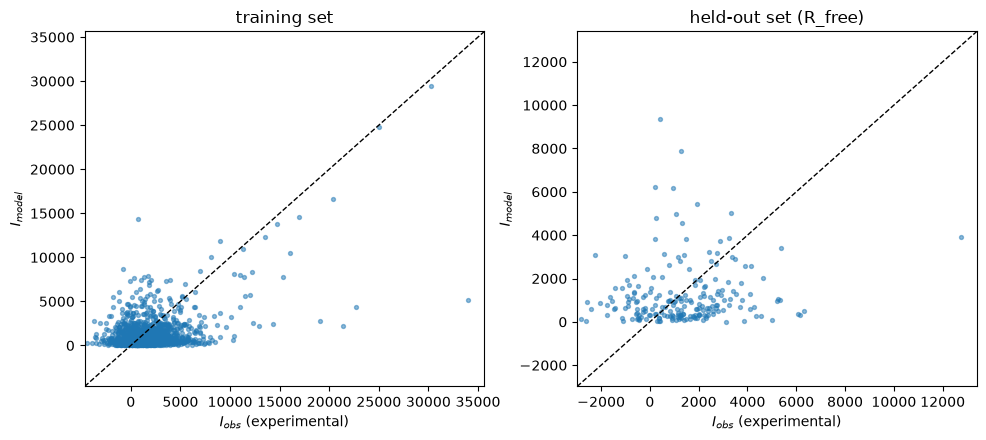

In [27]:
def R_factor(K_lab, q_list, G_list, I_list, scale=1.0):
    Imodel = scale * np.array([forward_I(K_lab, *q, G=G) for q, G in zip(q_list, G_list)])
    return np.sum(np.abs(Imodel - I_list)) / np.sum(np.abs(I_list)), Imodel

# S_FIT (from the training set only) is applied to both R and R_free here,
# so R_free still measures genuine out-of-sample agreement -- it just also
# gets the benefit of the same overall-scale correction as the training fit,
# rather than being penalized by a scale mismatch that has nothing to do
# with how well K itself generalizes.
R_train, I_model_train = R_factor(K_LAB_FIT, q_train, G_train, I_train, scale=S_FIT)
R_free,  I_model_test  = R_factor(K_LAB_FIT, q_test,  G_test,  I_test,  scale=S_FIT)
print(f"R (training set):  {R_train:.4f}")
print(f"R_free (held out): {R_free:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
for ax, Im, Io, title in [(axes[0], I_model_train, I_train, 'training set'),
                          (axes[1], I_model_test,  I_test,  'held-out set (R_free)')]:
    ax.scatter(Io, Im, s=8, alpha=0.5)
    lim = [min(Io.min(), Im.min())*1.05 if min(Io.min(),Im.min())<0 else 0,
           max(Io.max(), Im.max())*1.05]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('$I_{obs}$ (experimental)'); ax.set_ylabel('$I_{model}$'); ax.set_title(title)
plt.tight_layout(); plt.savefig('refinement_fit_quality.png', dpi=150); plt.show()


## Experimental vs. Fitted Diffuse Scattering

The experimental $l=0$ plane (a single slice read directly from the HDF5
file) next to the model's prediction on **exactly the same** $(h,k)$ grid
points (subsampled by `PLANE_STRIDE`, see below). The refinement above only
ever saw `I_train` at the sampled q-points; this map compares the two
everywhere in the plane, including regions with no training data nearby.

A full experimental plane can be a few hundred thousand $(h,k)$ points, and
unlike the scattered q-points used for fitting, $G(\mathbf q)$ here has to be
evaluated at *every one of them* — at $O(N_{\rm grid})$ work per point (the
direct Fourier sum above), that dominates the cost of this one cell.
`PLANE_STRIDE` subsamples the plane in both $h$ and $k$ (evaluating and
comparing on a coarser grid, `stride`$^2$ fewer points) purely as a runtime
control for this visualization — it does not affect the refinement itself,
which already uses the full, ungridded set of experimental points.

As before, the two intensity panels are $\log_{10}(1+I)$, but the two
residual panels are **not** log-transformed. The absolute-residual colorbar
is literally $I_{\rm fit}-I_{\rm exp}$ in the same units as $I$ itself, and
because $I$ spans many orders of magnitude between the acoustic halos and
the weak mid-zone signal, that residual is dominated by whatever happens
right at the brightest halo pixels even when the fit is good everywhere
else. The relative-residual panel, $(I_{\rm fit}-I_{\rm exp})/I_{\rm exp}$
clipped to $\pm100\%$, corrects for that by dividing out the local
intensity scale. Voxels that were NaN (outside the measured/asymmetric-unit
region) in the experimental map are masked out of all four panels.


Comparison plane: 35×61 points (stride=10, full plane would be 341×605)


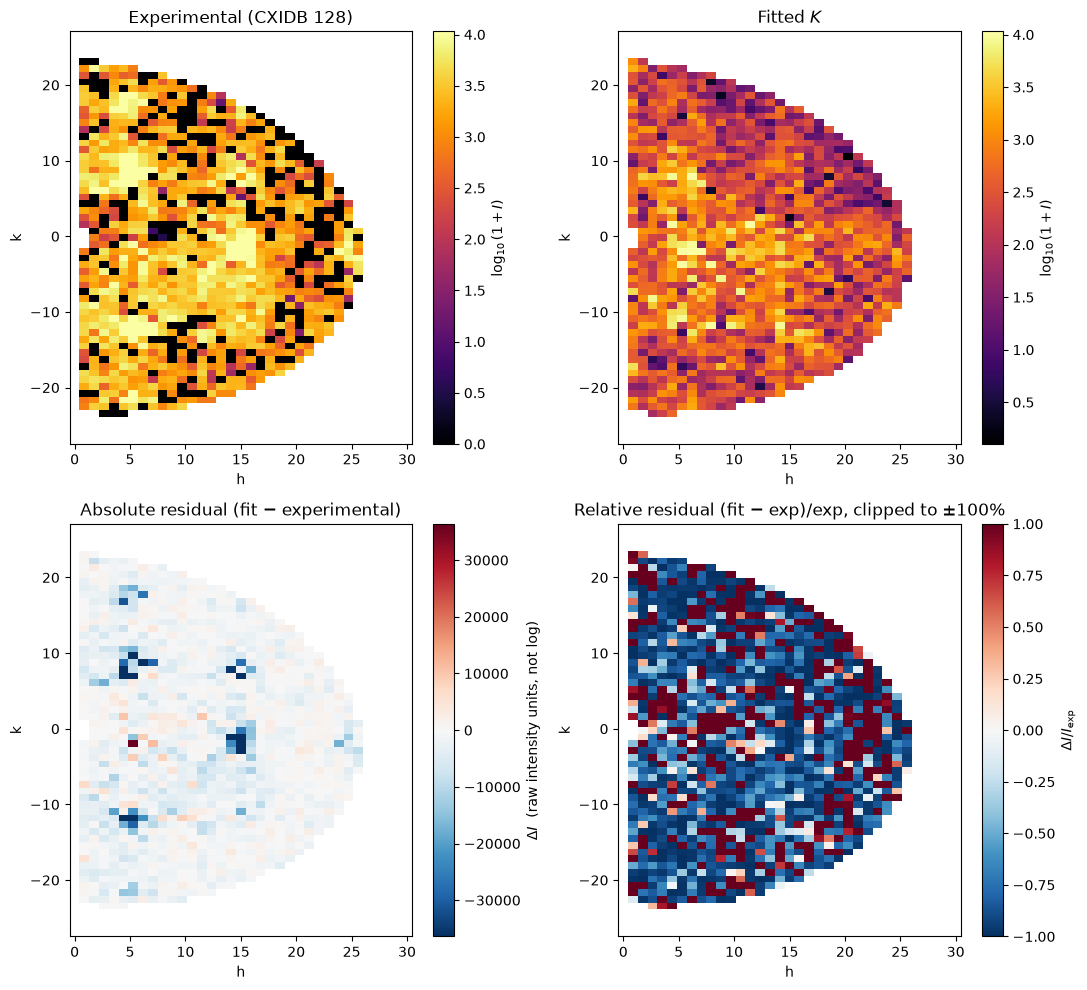

Saved diffuse_map_experimental_vs_fit_hk0.png
Absolute residual RMS: 9029  (I_exp RMS: 9344)
Relative residual, unclipped — median |·|: 0.933, 90th pct |·|: 1.75


In [28]:
PLANE_STRIDE = 10  # >1 subsamples the (h,k) comparison plane to cut runtime
                   # (stride**2 fewer points); the refinement itself is
                   # unaffected -- it never used this plane's grid

def predicted_plane(K_lab, h_pts, k_pts, l_layer, scale=1.0):
    HH, KK = np.meshgrid(h_pts, k_pts, indexing='ij')
    h_flat, k_flat = HH.ravel(), KK.ravel()
    l_flat = np.full_like(h_flat, l_layer)
    I_flat = scale * predict_I_batch(K_lab, h_flat, k_flat, l_flat)
    return I_flat.reshape(HH.shape)

h_pts_cmp0 = h_pts_bg0[::PLANE_STRIDE]
k_pts_cmp0 = k_pts_bg0[::PLANE_STRIDE]
I_bg0_cmp  = I_bg0[::PLANE_STRIDE, ::PLANE_STRIDE]
print(f"Comparison plane: {len(h_pts_cmp0)}×{len(k_pts_cmp0)} points "
      f"(stride={PLANE_STRIDE}, full plane would be {len(h_pts_bg0)}×{len(k_pts_bg0)})")

I_fit_map0 = predicted_plane(K_LAB_FIT, h_pts_cmp0, k_pts_cmp0, l_layer_0, scale=S_FIT)
exp_mask0  = np.isfinite(I_bg0_cmp)

def plot_diffuse_comparison(h_pts, k_pts, I_exp, I_fit, mask, fname, rel_clip=1.0):
    I_exp_m = np.where(mask, I_exp, np.nan)
    I_fit_m = np.where(mask, I_fit, np.nan)
    pos_vals = np.concatenate([I_exp_m[mask & (I_exp_m > 0)], I_fit_m[mask & (I_fit_m > 0)]])
    vmax = np.percentile(pos_vals, 97) if len(pos_vals) else 1.0
    resid = np.where(mask, I_fit_m - I_exp_m, np.nan)
    rmax = np.nanpercentile(np.abs(resid), 99) if np.isfinite(resid).any() else 1.0

    floor = 0.02 * vmax
    rel = resid / np.maximum(np.abs(I_exp_m), floor)
    rel_disp = np.clip(rel, -rel_clip, rel_clip)

    extent = [h_pts[0], h_pts[-1], k_pts[0], k_pts[-1]]
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))

    im0 = axes[0,0].imshow((np.log1p(np.clip(I_exp_m, 0, vmax)) / np.log(10)).T, origin='lower',
                           cmap='inferno', extent=extent, aspect='auto')
    axes[0,0].set_title('Experimental (CXIDB 128)')
    plt.colorbar(im0, ax=axes[0,0], label=r'$\log_{10}(1+I)$')

    im1 = axes[0,1].imshow((np.log1p(np.clip(I_fit_m, 0, vmax)) / np.log(10)).T, origin='lower',
                           cmap='inferno', extent=extent, aspect='auto')
    axes[0,1].set_title('Fitted $K$')
    plt.colorbar(im1, ax=axes[0,1], label=r'$\log_{10}(1+I)$')

    im2 = axes[1,0].imshow(resid.T, origin='lower', cmap='RdBu_r',
                           extent=extent, aspect='auto', vmin=-rmax, vmax=rmax)
    axes[1,0].set_title('Absolute residual (fit − experimental)')
    plt.colorbar(im2, ax=axes[1,0], label='$\\Delta I$  (raw intensity units, not log)')

    im3 = axes[1,1].imshow(rel_disp.T, origin='lower', cmap='RdBu_r',
                           extent=extent, aspect='auto', vmin=-rel_clip, vmax=rel_clip)
    axes[1,1].set_title(f'Relative residual (fit − exp)/exp, clipped to ±{100*rel_clip:.0f}%')
    plt.colorbar(im3, ax=axes[1,1], label='$\\Delta I / I_{\\rm exp}$')

    for ax in axes.flat:
        ax.set_xlabel('h'); ax.set_ylabel('k')
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

    rms_resid = np.sqrt(np.nanmean(resid**2))
    rms_exp   = np.sqrt(np.nanmean(I_exp_m**2))
    print(f"Saved {fname}")
    print(f"Absolute residual RMS: {rms_resid:.4g}  (I_exp RMS: {rms_exp:.4g})")
    print(f"Relative residual, unclipped — median |·|: {np.nanmedian(np.abs(rel)):.3g}, "
          f"90th pct |·|: {np.nanpercentile(np.abs(rel), 90):.3g}")

plot_diffuse_comparison(h_pts_cmp0, k_pts_cmp0, I_bg0_cmp, I_fit_map0, exp_mask0,
                        'diffuse_map_experimental_vs_fit_hk0.png')


## Predicted vs. Deposited Atomic Displacement Parameters

The single-cell generalized-coordinate covariance
$\Sigma=\langle(\Omega,v)(\Omega,v)^{\mathsf T}\rangle$ follows from
integrating $D(\mathbf q)^{-1}=\sum_s e_s(\mathbf q)e_s(\mathbf q)^{\mathsf T}
/\omega_s^2(\mathbf q)$ over the Brillouin zone (with the same eigenvalue
floor used elsewhere, to drop the acoustic zero modes at $\mathbf q=0$).
Projecting onto an atom at position $\mathbf r$ via
$\delta\mathbf r = v+\Omega\times(\mathbf r-\mathbf r_{\rm cm})$ gives that
atom's full $3\times3$ anisotropic displacement tensor
$U=J\Sigma J^{\mathsf T}$ — the same object a crystallographic ANISOU record
holds — with the familiar isotropic $B=\tfrac{8\pi^2}{3}\mathrm{Tr}(U)$ as
its trace.

This is the real validation this notebook has been building towards: the
model was fit **only** to the experimental diffuse-scattering data, so its
predicted $B$-factors and (where deposited) full ANISOU tensors are an
independent check against the atomic displacement parameters the deposited
6o2h structure was separately refined to from Bragg data.


In [29]:
# bz_covariance / atom_adp_tensors / isotropic_B are already defined above
# (right after dynamical_matrix_batch) -- they were needed early, right after
# refinement, to calibrate K_LAB_FIT's overall scale against the deposited
# mean B-factor. K_LAB_FIT here is already that calibrated K, so this is
# mostly a restatement/consistency check: the calibration was constructed to
# make the MEAN match exactly, but per-atom and per-residue detail (below)
# was never touched by it and is a genuine test of the fit.
Sigma_fit = bz_covariance(K_LAB_FIT)
U_fit  = atom_adp_tensors(Sigma_fit, apos)
B_fit  = isotropic_B(U_fit)
print(f"Mean predicted B (fitted K):  {B_fit.mean():.2f} Å²")
print(f"Mean deposited B (6o2h):      {b_exp.mean():.2f} Å²")


Mean predicted B (fitted K):  13.11 Å²
Mean deposited B (6o2h):      13.11 Å²


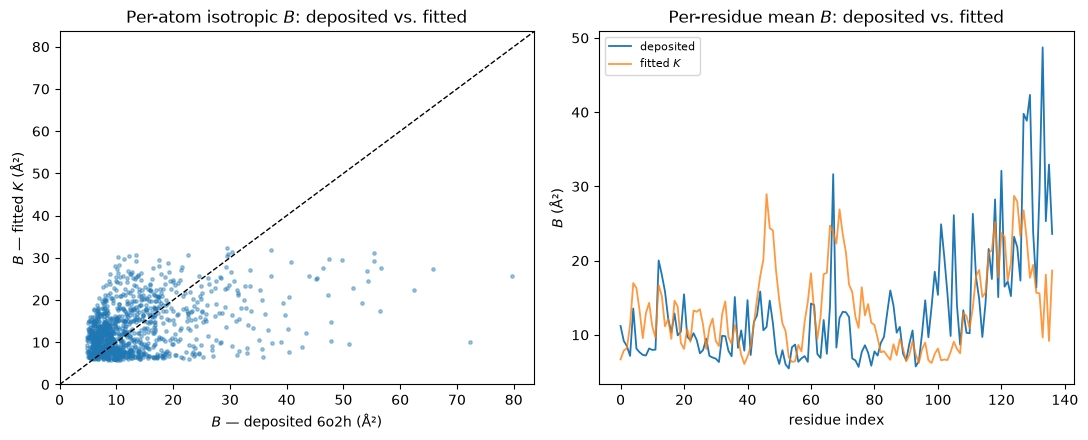

Pearson correlation, per-atom isotropic B (deposited vs. fitted): 0.399


In [30]:
# Per-residue means, compared directly (deposited vs. fitted, same units)
res_ids = []
for ch in st[0]:
    for res in ch:
        for atom in res:
            res_ids.append((ch.name, res.seqid.num))
res_index = {}
res_inverse = np.empty(len(res_ids), dtype=int)
for i, key in enumerate(res_ids):
    res_inverse[i] = res_index.setdefault(key, len(res_index))
n_res = len(res_index)
def per_residue_mean(x):
    out = np.zeros(n_res)
    counts = np.zeros(n_res)
    for v, r in zip(x, res_inverse):
        out[r] += v; counts[r] += 1
    return out / counts

B_exp_res, B_fit_res = per_residue_mean(b_exp), per_residue_mean(B_fit)

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

ax = axes[0]
ax.scatter(b_exp, B_fit, s=6, alpha=0.4)
lim = [0, max(b_exp.max(), B_fit.max())*1.05]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('$B$ — deposited 6o2h (Å²)'); ax.set_ylabel('$B$ — fitted $K$ (Å²)')
ax.set_title('Per-atom isotropic $B$: deposited vs. fitted')

ax = axes[1]
ax.plot(B_exp_res, label='deposited', lw=1.3)
ax.plot(B_fit_res, label='fitted $K$', lw=1.3, alpha=0.8)
ax.set_xlabel('residue index'); ax.set_ylabel('$B$ (Å²)')
ax.set_title('Per-residue mean $B$: deposited vs. fitted')
ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig('adp_comparison.png', dpi=150); plt.show()

pearson_r = np.corrcoef(b_exp, B_fit)[0,1]
print(f"Pearson correlation, per-atom isotropic B (deposited vs. fitted): {pearson_r:.3f}")


### Anisotropic Comparison

The isotropic trace above discards the shape of each atom's displacement
ellipsoid. Where 6o2h carries deposited ANISOU records, the full tensor
comparison checks whether the refinement also recovers that shape: the six
independent components of $U$ plotted against each other (deposited vs.
fitted, pooled over all atoms with ANISOU present), and each atom's
anisotropy ratio (largest/smallest principal displacement) — a model that
only matches on the isotropic trace but gets the anisotropy wrong would show
good agreement in the $B$-factor plots above but poor agreement here.


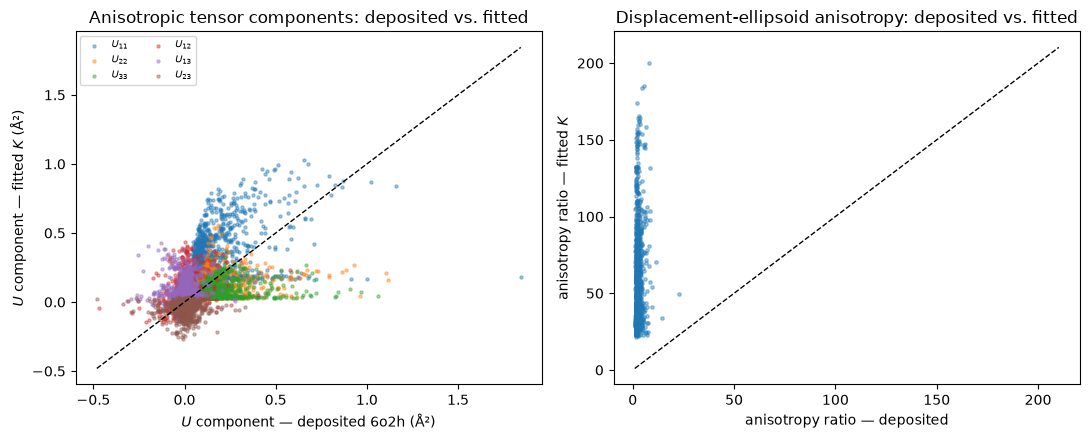

In [31]:
def anisotropy_ratio(U):
    ev = np.linalg.eigvalsh(U)
    return ev[:, -1] / np.clip(ev[:, 0], 1e-12, None)

comp_idx   = [(0,0),(1,1),(2,2),(0,1),(0,2),(1,2)]
comp_names = ['$U_{11}$','$U_{22}$','$U_{33}$','$U_{12}$','$U_{13}$','$U_{23}$']

if has_aniso.mean() > 0.3:
    fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

    ax = axes[0]
    for (i,j), name in zip(comp_idx, comp_names):
        ax.scatter(u_exp[has_aniso,i,j], U_fit[has_aniso,i,j], s=5, alpha=0.4, label=name)
    lim = [min(u_exp[has_aniso].min(), U_fit[has_aniso].min()),
           max(u_exp[has_aniso].max(), U_fit[has_aniso].max())]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlabel('$U$ component — deposited 6o2h (Å²)'); ax.set_ylabel('$U$ component — fitted $K$ (Å²)')
    ax.set_title('Anisotropic tensor components: deposited vs. fitted')
    ax.legend(fontsize=7, ncol=2)

    ax = axes[1]
    aniso_exp = anisotropy_ratio(u_exp[has_aniso])
    aniso_fit = anisotropy_ratio(U_fit[has_aniso])
    ax.scatter(aniso_exp, aniso_fit, s=6, alpha=0.4)
    lim2 = [1, max(aniso_exp.max(), aniso_fit.max())*1.05]
    ax.plot(lim2, lim2, 'k--', lw=1)
    ax.set_xlabel('anisotropy ratio — deposited'); ax.set_ylabel('anisotropy ratio — fitted $K$')
    ax.set_title('Displacement-ellipsoid anisotropy: deposited vs. fitted')

    plt.tight_layout(); plt.savefig('adp_anisotropic_comparison.png', dpi=150); plt.show()
else:
    print(f"Only {has_aniso.mean():.1%} of atoms in 6o2h carry ANISOU records; "
          f"skipping the anisotropic comparison. Isotropic B-factors are "
          f"compared above regardless.")


## Phonon Mode Visualization

Each phonon mode at a chosen $\mathbf q$-point is rendered as a looping GIF
of the rigid-body motion, using the model **fitted to the experimental
data**. $|\Omega|$ and $|v|$ are the rotational and translational norms of
the mass-weighted eigenvector (normalized so
$\Omega^{\mathsf T}J\Omega+v^{\mathsf T}mv=1$); their ratio gives the
rotational kinetic-energy fraction, used below to label each mode
librational, translational, or mixed. Displacement amplitude is defined as
the largest per-atom displacement in Å, not the center-of-mass displacement.


In [32]:
Q_VIZ     = np.array([0.5, 0.25, 0.0])  # fractional — zone-boundary, off-axis
AMPLITUDE = 3.0    # Å — maximum per-atom displacement
N_FRAMES  = 30
GIF_FPS   = 12

q_viz  = B_recip @ Q_VIZ
D_viz  = dynamical_matrix(q_viz, unique, K_LAB_FIT)
Dw_viz = (Msq_inv @ D_viz @ Msq_inv.T).real
ev_v, evec_v = np.linalg.eigh(Dw_viz)
ev_v      = np.maximum(ev_v, 0)
freqs_viz = np.sqrt(ev_v) * freq_unit
evecs_lab = Msq_inv.T @ evec_v

print(f"Modes at q={Q_VIZ}:")
hdr = f"{'Mode':>5} {'Freq (THz)':>14} {'|Ω|':>9} {'|v|':>9}  {'rot KE %':>9}  character"
print(hdr); print('-'*len(hdr))
for s in range(6):
    Om = evecs_lab[:3, s].real; v = evecs_lab[3:, s].real
    rot_KE, trans_KE = float(Om @ J @ Om), float(m_total * (v@v))
    rot_pct = 100 * rot_KE / max(rot_KE + trans_KE, 1e-30)
    char = 'librational' if rot_pct > 60 else ('translational' if rot_pct < 40 else 'mixed')
    print(f"  {s:3d}  {freqs_viz[s]:14.6f}  {np.linalg.norm(Om):9.4f}  "
          f"{np.linalg.norm(v):9.4f}  {rot_pct:9.1f}%  {char}")


Modes at q=[0.5  0.25 0.  ]:
 Mode     Freq (THz)       |Ω|       |v|   rot KE %  character
--------------------------------------------------------------
    0        0.039216     0.0006     0.0018       94.8%  librational
    1        0.110988     0.0002     0.0078        5.8%  translational
    2        0.133850     0.0001     0.0080        0.9%  translational
    3        0.268276     0.0003     0.0076       11.7%  translational
    4        1.303418     0.0007     0.0008       99.1%  librational
    5        1.940517     0.0008     0.0028       87.8%  librational


In [33]:
# Molecular isosurface: marching cubes on the hybrid model density, downsampled
# for speed, keeping only the largest connected component so periodic-image
# and solvent-void fragments are discarded, then Lambert-shaded per face so
# shape and roughness stay visible even at partial transparency.
base_pos = apos.copy()
pts_cm   = base_pos - r_cm_at

MC_DS = 0.5
rho_mc = nd_zoom(rho_model.astype(np.float32), MC_DS, order=1)
nu_mc, nv_mc, nw_mc = rho_mc.shape
_iso_level = rho_mc.max() * 0.05
mc_verts_grid, mc_faces_raw, _normals, _vals = marching_cubes(rho_mc, level=_iso_level)
_frac = mc_verts_grid / np.array([nu_mc, nv_mc, nw_mc])
mc_verts_raw = (A_orth @ _frac.T).T

def _largest_component(verts, faces):
    n = len(verts)
    idx_i = np.concatenate([faces[:,0], faces[:,1], faces[:,2]])
    idx_j = np.concatenate([faces[:,1], faces[:,2], faces[:,0]])
    adj   = csr_matrix((np.ones(len(idx_i), dtype=np.int8), (idx_i, idx_j)), shape=(n, n))
    _, labels = sc_connected_components(adj, directed=False)
    keep_label = np.bincount(labels).argmax()
    keep = np.where(labels == keep_label)[0]
    remap = np.full(n, -1, dtype=int); remap[keep] = np.arange(len(keep))
    face_ok = (labels[faces] == keep_label).all(axis=1)
    return verts[keep], remap[faces[face_ok]]

mc_verts_cart, mc_faces = _largest_component(mc_verts_raw, mc_faces_raw)
mc_verts_cm = mc_verts_cart - r_cm_at
print(f"Isosurface: {len(mc_verts_cm)} verts, {len(mc_faces)} tris "
      f"(largest connected component, level={_iso_level:.3f} e/Å³)")

_LIGHT = np.array([0.5, 0.8, 1.0]); _LIGHT /= np.linalg.norm(_LIGHT)

def _shade(tri_array, hex_color, alpha, ambient=0.35):
    v0, v1, v2 = tri_array[:,0], tri_array[:,1], tri_array[:,2]
    n = np.cross(v1 - v0, v2 - v0)
    mag = np.linalg.norm(n, axis=1, keepdims=True)
    n /= np.where(mag > 1e-12, mag, 1.0)
    intensity = ambient + (1 - ambient) * np.abs(n @ _LIGHT)
    r = int(hex_color[1:3], 16) / 255
    g = int(hex_color[3:5], 16) / 255
    b = int(hex_color[5:7], 16) / 255
    return np.column_stack([intensity*r, intensity*g, intensity*b, np.full(len(tri_array), alpha)])

def displaced_mc(mode_idx, scale):
    Om_raw = evecs_lab[:3, mode_idx].real.copy()
    v_raw  = evecs_lab[3:, mode_idx].real.copy()
    norm_vec = np.sqrt(Om_raw @ Om_raw + v_raw @ v_raw)
    if norm_vec < 1e-10:
        return mc_verts_cm + r_cm_at
    Om_u, v_u = Om_raw/norm_vec, v_raw/norm_vec
    delta_unit = v_u[None,:] + np.cross(Om_u[None,:], pts_cm)
    max_d = np.linalg.norm(delta_unit, axis=1).max()
    if max_d < 1e-12:
        return mc_verts_cm + r_cm_at
    fac = scale / max_d
    Om_s, v_s = fac*Om_u, fac*v_u
    if abs(fac)*np.linalg.norm(Om_u) > 1e-10:
        return Rot.from_rotvec(Om_s).apply(mc_verts_cm) + r_cm_at + v_s
    return mc_verts_cm + r_cm_at + v_s

eq_bbox_min = mc_verts_cart.min(axis=0)
eq_bbox_max = mc_verts_cart.max(axis=0)


Isosurface: 10744 verts, 21090 tris (largest connected component, level=0.404 e/Å³)


In [34]:
MODE_COLORS = ['#4e9de0', '#e05c5c', '#4fba74', '#e0b14e', '#a56be0', '#e07e4e']
SURF_ALPHA  = 0.65
ELEV, AZIM  = 20, -60

def make_mode_gif(mode_idx, amplitude=AMPLITUDE, n_frames=N_FRAMES, fps=GIF_FPS, fname=None, figsize=(6,5)):
    """Render one phonon mode as a looping GIF and save it to disk (no
    in-notebook display, and memory is freed after each mode)."""
    if fname is None:
        qstr = '_'.join(f'{x:.2f}' for x in Q_VIZ)
        fname = f'mode_{mode_idx}_q{qstr}.gif'
    color  = MODE_COLORS[mode_idx % len(MODE_COLORS)]
    scales = amplitude * np.sin(2*np.pi*np.arange(n_frames)/n_frames)
    pad = amplitude * 2.5
    xlim = (eq_bbox_min[0]-pad, eq_bbox_max[0]+pad)
    ylim = (eq_bbox_min[1]-pad, eq_bbox_max[1]+pad)
    zlim = (eq_bbox_min[2]-pad, eq_bbox_max[2]+pad)

    Om_r = evecs_lab[:3, mode_idx].real
    rot_KE   = float(Om_r @ J @ Om_r)
    trans_KE = m_total * float(np.linalg.norm(evecs_lab[3:, mode_idx].real)**2)
    rot_pct  = 100*rot_KE/(rot_KE+trans_KE+1e-30)

    images = []
    for sc in scales:
        fig = plt.figure(figsize=figsize, facecolor='#0d1117')
        ax  = fig.add_subplot(111, projection='3d', facecolor='#0d1117')
        try:
            verts = displaced_mc(mode_idx, sc)
            tris  = verts[mc_faces]
            rgba  = _shade(tris, color, SURF_ALPHA)
            poly  = Poly3DCollection(tris, facecolors=rgba, linewidths=0, edgecolor='none')
            ax.add_collection3d(poly)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
            ax.set_axis_off(); ax.view_init(elev=ELEV, azim=AZIM)
            ax.set_title(f'Mode {mode_idx}   {freqs_viz[mode_idx]:.4f} THz\n'
                         f'q={list(Q_VIZ)}   rot {rot_pct:.0f}%  trans {100-rot_pct:.0f}%',
                         color='white', fontsize=8.5, pad=3)
            plt.tight_layout(pad=0.2)
            images.append(fig_to_image(fig))
        finally:
            plt.close(fig)

    imageio.mimsave(fname, images, fps=fps, loop=0)
    del images; gc.collect()
    return fname

print(f"Generating surface GIFs at q={Q_VIZ} (amplitude={AMPLITUDE} Å max per-atom)...")
for s in range(6):
    print(f"Mode {s}: {freqs_viz[s]:.6f} THz", end="  ... ")
    try:
        path = make_mode_gif(s)
        print(f"saved -> {path}")
    except Exception as e:
        print(f"FAILED: {e}")
    gc.collect()
print("Load any GIF with: display(IPImage(filename='mode_N_q....gif'))")


Generating surface GIFs at q=[0.5  0.25 0.  ] (amplitude=3.0 Å max per-atom)...
Mode 0: 0.039216 THz  ... saved -> mode_0_q0.50_0.25_0.00.gif
Mode 1: 0.110988 THz  ... saved -> mode_1_q0.50_0.25_0.00.gif
Mode 2: 0.133850 THz  ... saved -> mode_2_q0.50_0.25_0.00.gif
Mode 3: 0.268276 THz  ... saved -> mode_3_q0.50_0.25_0.00.gif
Mode 4: 1.303418 THz  ... saved -> mode_4_q0.50_0.25_0.00.gif
Mode 5: 1.940517 THz  ... saved -> mode_5_q0.50_0.25_0.00.gif
Load any GIF with: display(IPImage(filename='mode_N_q....gif'))


In [35]:
# Supercell wave: each cell (i,j,k) is a rigid copy displaced by
# amplitude * cos(2*pi*q_frac.[i,j,k] + phase). The central cell is
# colored distinctly from its neighbors so the propagating wave pattern
# can be read off against a fixed reference point.
SUPER_N1, SUPER_N2, SUPER_N3 = 3, 3, 1   # a full 3x3x3 renders 27 isosurfaces per
                                          # frame and can exhaust notebook-kernel memory;
                                          # 3x3x1 already shows the in-plane wave pattern
MODE_SUPER   = 0
SUPER_COLOR  = '#4e9de0'
SUPER_ALPHA  = 0.38
CENTER_COLOR = '#e05c5c'
CENTER_ALPHA = 0.55

def make_supercell_gif(mode_idx=MODE_SUPER, amplitude=AMPLITUDE, n_frames=N_FRAMES, fps=GIF_FPS,
                       n1=SUPER_N1, n2=SUPER_N2, n3=SUPER_N3, fname=None, figsize=(10,9)):
    if fname is None:
        qstr = '_'.join(f'{x:.2f}' for x in Q_VIZ)
        fname = f'supercell_mode{mode_idx}_q{qstr}.gif'

    cells_ijk = [(i,j,k) for i in range(n1) for j in range(n2) for k in range(n3)]
    center_ijk = (n1//2, n2//2, n3//2)
    phase0 = np.array([2*np.pi*(Q_VIZ[0]*i + Q_VIZ[1]*j + Q_VIZ[2]*k) for i,j,k in cells_ijk])
    T_cell = np.array([i*a1 + j*a2 + k*a3 for i,j,k in cells_ijk])

    all_eq = np.vstack([mc_verts_cart + T for T in T_cell])
    pad = amplitude * 2.5
    xlim = (all_eq[:,0].min()-pad, all_eq[:,0].max()+pad)
    ylim = (all_eq[:,1].min()-pad, all_eq[:,1].max()+pad)
    zlim = (all_eq[:,2].min()-pad, all_eq[:,2].max()+pad)

    images = []
    for fi in range(n_frames):
        t = 2*np.pi*fi/n_frames
        fig = plt.figure(figsize=figsize, facecolor='#0d1117')
        ax  = fig.add_subplot(111, projection='3d', facecolor='#0d1117')
        try:
            for (i,j,k), T, ph0 in zip(cells_ijk, T_cell, phase0):
                sc = amplitude * np.cos(ph0 + t)
                verts = displaced_mc(mode_idx, sc) + T
                tris_v = verts[mc_faces]
                is_center = (i,j,k) == center_ijk
                color = CENTER_COLOR if is_center else SUPER_COLOR
                alpha = CENTER_ALPHA if is_center else SUPER_ALPHA
                rgba = _shade(tris_v, color, alpha)
                poly = Poly3DCollection(tris_v, facecolors=rgba, linewidths=0, edgecolor='none')
                ax.add_collection3d(poly)

            ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
            ax.set_axis_off(); ax.view_init(elev=25, azim=-55)
            ax.set_title(f'Supercell phonon — Mode {mode_idx}  {freqs_viz[mode_idx]:.4f} THz\n'
                         f'q={list(Q_VIZ)}   {n1}×{n2}×{n3} cells (center cell highlighted)',
                         color='white', fontsize=8.5, pad=3)
            plt.tight_layout(pad=0.2)
            images.append(fig_to_image(fig))
        finally:
            plt.close(fig)

    imageio.mimsave(fname, images, fps=fps, loop=0)
    del images; gc.collect()
    return fname

print(f"Generating {SUPER_N1}×{SUPER_N2}×{SUPER_N3} supercell GIF for mode {MODE_SUPER}...")
try:
    sc_path = make_supercell_gif()
    print(f"Saved -> {sc_path}")
except Exception as e:
    print(f"Supercell GIF failed: {e}")
    import traceback; traceback.print_exc()


Generating 3×3×1 supercell GIF for mode 0...
Saved -> supercell_mode0_q0.50_0.25_0.00.gif


## Summary

| Output | File | Description |
|--------|------|-------------|
| Band structure (isotropic) | `band_structure_isotropic.png` | Phonon dispersion Γ–X–Y–Z–Γ before fitting |
| Resolution/SNR scan | `resolution_snr_scan.png` | Data-driven choice of the fitting resolution shell |
| Sampled q-points | `sampled_q_points.png` | 3D Cartesian view plus per-layer overlays on the experimental map |
| Refinement fit quality | `refinement_fit_quality.png` | $I_{\rm obs}$ vs $I_{\rm model}$, training and $R_{\rm free}$ sets |
| Band-structure convergence | `band_structure_convergence.gif` | Convergence toward the final fit, frame per L-BFGS-B iteration |
| Experimental vs. fitted map | `diffuse_map_experimental_vs_fit_hk0.png` | Experimental data, fitted $K$, and their residual, side by side |
| ADP comparison (isotropic) | `adp_comparison.png` | Per-atom and per-residue $B$-factor: deposited vs. fitted model |
| ADP comparison (anisotropic) | `adp_anisotropic_comparison.png` | Full $U$-tensor components and anisotropy ratio: deposited vs. fitted |
| Mode GIFs | `mode_N_q*.gif` | All 6 modes at the chosen q-point, fitted model |
| Supercell wave | `supercell_mode*.gif` | 3×3×1 supercell phonon wave, center cell highlighted |

**Contact stiffness parameterization.** Each symmetry-distinct contact
carries an independent $6\times6$ stiffness, specified in a local frame
anchored at the measured contact centroid via a Cholesky factor
($K=LL^{\mathsf T}$, guaranteeing positive-definiteness, hence stability, for
any real $L$) and regularized toward zero translation–rotation coupling in
that local frame only.

**Data-driven resolution and grid matching.** The per-axis oversampling
$(P_1,P_2,P_3)$ used for the model's own fine reciprocal grid, and the
resolution shell used for refinement, are both read or derived from the
experimental map's own metadata rather than assumed — so model and data are
compared on exactly the same $(h,k,l)$ points, at a resolution the data can
actually support.

**Refinement.** L-BFGS-B on the Cholesky parameters, using an analytic
gradient of $I(\mathbf q)=G^\dagger D^{-1}G$ derived from the matrix-inverse
identity and verified against finite differences, fit directly to the
experimental diffuse intensities and their reported uncertainties. Training
and held-out $R$-factors are reported to check against overfitting, and the
fitted model's predicted atomic displacement parameters are compared against
the deposited structure's own refined B-factors and ANISOU records — the
real validation of the whole pipeline.
